# Surrogate Model Stress Test (qubit_TransmonCross_cap_matrix)
## Gaussian Augmentation + Brute Force Search

We are going to generate thousands of augmented Qiskit Metal parameter sets by adding Gaussian noise based on qiskit metal params of test samples. Then well run them through the surrogate model to predict the capacitance, and save the best
ones to simulate in Ansys HFSS.

## Configuration

In [1]:
from parameters_surrogate import *

## Library

In [2]:
import os, gc, math, time
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from tensorflow.keras.models import load_model

## Load Dataset & Surrogate Model

In [3]:
def load_scaled_split(kind, split):
    return np.load(f'{DATA_DIR}/npy/{split}_{kind}_encoding_scaled.npy', allow_pickle=True)

X_train = load_scaled_split('linear', 'y_train')
X_val   = load_scaled_split('linear', 'y_val')
X_test  = load_scaled_split('linear', 'y_test')

y_train = load_scaled_split('linear', 'x_train')
y_val   = load_scaled_split('linear', 'x_val')
y_test  = load_scaled_split('linear', 'x_test')

with open('X_names', 'r') as f:
    Hamiltonian_column_names = f.read().splitlines()

qiskit_param_names = np.load('y_columns.npy', allow_pickle=True).astype(str).tolist()

print(f'Inputs (Qiskit params):  {X_train.shape[1]} columns: {qiskit_param_names}')
print(f'Outputs (Capacitance):   {y_train.shape[1]} columns: {Hamiltonian_column_names}')
print(f'Training samples: {len(X_train)}, Test samples: {len(X_test)}')

Inputs (Qiskit params):  3 columns: ['design_options.connection_pads.readout.claw_length', 'design_options.connection_pads.readout.ground_spacing', 'design_options.cross_length']
Outputs (Capacitance):   2 columns: ['qubit_frequency_GHz', 'anharmonicity_MHz']
Training samples: 1353, Test samples: 291


In [4]:
tf.keras.backend.clear_session()
gc.collect()

chosen_path = 'model/best_keras_model_model2_surrogate.keras'
with tf.device('/CPU:0'):
    surrogate = load_model(chosen_path, compile=False)

print(f'Loaded surrogate: {chosen_path}')
surrogate.summary()

Loaded surrogate: model/best_keras_model_model2_surrogate.keras


I0000 00:00:1776382465.369101   19373 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18166 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 2g.20gb, pci bus id: 0000:00:11.0, compute capability: 8.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc0 (Dense)                     │ (None, 736)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu0 (LeakyReLU)         │ (None, 736)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout0 (Dropout)              │ (None, 736)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │         1,474 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,418 (17.26 KB)

 Trainable params: 4,418 (17.26 KB)

 Non-trainable params: 0 (0.00 B)

## Load Scalers for Unscaling

In [5]:
# Load all scalers so we can go back and forth between scaled and unscaled
qiskit_scalers = {}
for name in qiskit_param_names:
    qiskit_scalers[name] = joblib.load(f'scalers/scaler_y_linear_{name}.save')

Hamiltonian_scalers = {}
for name in Hamiltonian_column_names:
    Hamiltonian_scalers[name] = joblib.load(f'scalers/scaler_X_linear_{name}.save')

def unscale_qiskit(X_scaled):
    """Unscale Qiskit Metal params from [0,1] back to real values."""
    X_out = X_scaled.copy()
    for j, name in enumerate(qiskit_param_names):
        X_out[:, j] = qiskit_scalers[name].inverse_transform(X_out[:, j:j+1]).ravel()
    return X_out

def scale_qiskit(X_real):
    """Scale real Qiskit Metal params to [0,1]."""
    X_out = X_real.copy()
    for j, name in enumerate(qiskit_param_names):
        X_out[:, j] = qiskit_scalers[name].transform(X_out[:, j:j+1]).ravel()
    return X_out

def unscale_Hamiltonian(y_scaled):
    """Unscale capacitance predictions back to real values."""
    y_out = y_scaled.copy()
    for j, name in enumerate(Hamiltonian_column_names):
        y_out[:, j] = Hamiltonian_scalers[name].inverse_transform(y_out[:, j:j+1]).ravel()
    return y_out

# Quick test
X_test_unscaled = unscale_qiskit(np.asarray(X_test))
print('Unscaled test set param ranges:')
for j, name in enumerate(qiskit_param_names):
    short = name.replace('design_options.', '')
    vals = X_test_unscaled[:, j]
    print(f'  {short:30s}  min={vals.min()}  max={vals.max()}  mean={vals.mean()}')

Unscaled test set param ranges:
  connection_pads.readout.claw_length  min=7e-05  max=0.00037  mean=0.00017103092783505154
  connection_pads.readout.ground_spacing  min=4.1e-06  max=1e-05  mean=7.091752577319587e-06
  cross_length                    min=9e-05  max=0.00042  mean=0.0002902405498281787


## Identify Integer vs Continuous Parameters

We need to know which parameters are integers (like finger_count) so we can
use different noise for those and Gaussian noise for the continuous ones.

In [6]:
#see if all of the training sets are integers for a specific column
X_all_unscaled = unscale_qiskit(np.vstack([X_train, X_val, X_test]).astype('float64'))

is_integer_param = []
integer_unique_vals = {}  
for j, name in enumerate(qiskit_param_names):
    vals = X_all_unscaled[:, j]
    all_integer = np.allclose(vals, np.round(vals))
    is_integer_param.append(all_integer)
    if all_integer:
        integer_unique_vals[j] = sorted(set(np.round(vals).astype(int)))
        print(f'  {name}: INTEGER — unique values: {integer_unique_vals[j]}')
    else:
        print(f'  {name}: CONTINUOUS — range [{vals.min()}, {vals.max()}]')

#figure out the range for each parameter
X_train_unscaled = unscale_qiskit(np.asarray(X_train).astype('float64'))
param_ranges = X_train_unscaled.max(axis=0) - X_train_unscaled.min(axis=0)
print(f'\nParameter ranges: {param_ranges}')

  design_options.connection_pads.readout.claw_length: CONTINUOUS — range [7e-05, 0.00039999999999999996]
  design_options.connection_pads.readout.ground_spacing: CONTINUOUS — range [4.1e-06, 1e-05]
  design_options.cross_length: CONTINUOUS — range [9e-05, 0.00042]

Parameter ranges: [3.3e-04 5.9e-06 3.3e-04]


In [7]:
max(X_train_unscaled[:,0])

0.00039999999999999996

## Make the gaussians and get the 'noisy' points

Pick some samples from the test set to center the gaussians on, then based on the gaussian associated with each one make 'noisy' copys.

Also here we try many sigma widths to see where the surrogate starts to fail

In [8]:
N_SEED_SAMPLES = 30          #how many real test samples to use as the gaussian centers
N_NOISY_PER_SEED = 200       #how many noisy copies per seed (total_points = N_SEED * N_NOISY)
SIGMA_FRACTIONS = [0.01, 0.02, 0.05, 0.10, 0.20,0.40]  # fraction of param range to use as sigma

np.random.seed(37) #set this to keep the 'random' selections the same on different trials

#get points from test set to center gaussian on 
seed_indices = np.random.choice(len(X_test), size=min(N_SEED_SAMPLES, len(X_test)), replace=False)
seed_samples_scaled = np.asarray(X_test)[seed_indices]
seed_samples_unscaled = unscale_qiskit(seed_samples_scaled.astype('float64'))
# getting their actual target Hamiltonian to compare to 
seed_Hamiltonian_scaled = np.asarray(y_test)[seed_indices]  

print(f'Selected {len(seed_indices)} seed samples from test set')
print(f'Will generate {N_NOISY_PER_SEED} noisy copies each at {len(SIGMA_FRACTIONS)} sigma levels')
print(f'Total augmented samples per sigma: {len(seed_indices) * N_NOISY_PER_SEED}')


Selected 30 seed samples from test set
Will generate 200 noisy copies each at 6 sigma levels
Total augmented samples per sigma: 6000


In [9]:
def generate_augmented(seed_unscaled, n_copies, sigma_fraction, param_ranges,
                       is_integer, integer_vals):
    #make noisy copies of a single sample. make sure everything is unscaled
    #everything is continuous so just add Gaussian noise with sigma=sigma_fraction*param_range
    
    n_params = len(seed_unscaled)
    print(n_params)
    copies = np.tile(seed_unscaled, (n_copies, 1)) 
    
    for j in range(n_params):
        sigma = sigma_fraction * param_ranges[j]
        noise = np.random.normal(0, sigma, size=n_copies)
        copies[:, j] += noise
    
    return copies


def generate_augmented_bounded(seed_unscaled, n_copies, sigma_fraction, param_ranges,
                       is_integer, integer_vals):
    #make noisy copies of a single sample. make sure everything is unscaled
    #everything is continuous so just add Gaussian noise with sigma=sigma_fraction*param_range
    
    n_params = len(seed_unscaled)
    copies = np.tile(seed_unscaled, (n_copies, 1)) 

    '''constraints needed to check validity of a noisy design '''
    ## single-valued SQuADDS params we do not train on ##
    claw_gap = 5.1 / 1e6 # in meters
    cross_gap = 30 / 1e6 # in meters

    ## boundaries of the training space ##
    max_claw_length = max(X_train_unscaled[:,0])
    min_claw_length = min(X_train_unscaled[:,0])
    max_ground_spacing = max(X_train_unscaled[:,1])
    min_ground_spacing = min(X_train_unscaled[:,1])
    max_cross_length = max(X_train_unscaled[:,2])
    min_cross_length = min(X_train_unscaled[:,2])

    ''' iterate through n_copies of the gaussian center''' 
    for k in range(len(copies)):

        valid_design = False

        ## unperturbed params ##
        inital_design = copies[k]

        while valid_design == False: # don't break until we have a valid design

            sigma1 = sigma_fraction * param_ranges[0] # claw length sigma
            sigma2 = sigma_fraction * param_ranges[1] # ground spacing sigma
            sigma3 = sigma_fraction * param_ranges[2] # cross length sigma
            
            noise1 = np.random.normal(0, sigma1, size=1) # claw length noise
            noise2 = np.random.normal(0, sigma2, size=1) # ground spacing noise
            noise3 = np.random.normal(0, sigma3, size=1) # cross length noise

            ## perturbed params ##
            claw_length = inital_design[0] + noise1
            claw_length = claw_length[0]
            ground_spacing = inital_design[1] + noise2
            ground_spacing = ground_spacing[0]
            cross_length = inital_design[2] + noise3
            cross_length = cross_length[0]

            ''' 
            constraints are as follows:
            1) ensure noisy designs fall within bounds of the training space
            2) ensure the coupling claw does not physically overlap with the transmon cross
            '''
            if ((claw_length >= min_claw_length and claw_length <= max_claw_length) and #1)
            (ground_spacing >= min_ground_spacing and ground_spacing <= max_ground_spacing) and #1)
            (cross_length >= min_cross_length and cross_length <= max_cross_length) and #1)
            (claw_length + 2*claw_gap) < (ground_spacing + cross_length)): # 2)
                valid_design = True 
                
        copies[k] = [claw_length,ground_spacing,cross_length]
    
    return copies

## Run each of the samples through the surrogate and time everything


----------------------------------------------------------------------
Sigma fraction: 0.01 (1% of param range)
----------------------------------------------------------------------
Running 6000 samples through surrogate...


/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
I0000 00:00:1776382465.771378   20037 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Time: 0.387s total, 64.4 μs/sample
  Mean % error: 0.930610%
  Median % error: 0.717406%
  90th percentile: 2.01%
  Max % error: 6.66%

----------------------------------------------------------------------
Sigma fraction: 0.02 (2% of param range)
----------------------------------------------------------------------


/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Running 6000 samples through surrogate...
  Time: 0.235s total, 39.1 μs/sample
  Mean % error: 1.783137%
  Median % error: 1.394971%
  90th percentile: 3.74%
  Max % error: 14.66%

----------------------------------------------------------------------
Sigma fraction: 0.05 (5% of param range)
----------------------------------------------------------------------
Running 6000 samples through surrogate...


...

  Time: 0.229s total, 38.2 μs/sample
  Mean % error: 8.035434%
  Median % error: 6.323910%
  90th percentile: 17.09%
  Max % error: 59.66%

----------------------------------------------------------------------
Sigma fraction: 0.2 (20% of param range)
----------------------------------------------------------------------


/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Running 6000 samples through surrogate...
  Time: 0.236s total, 39.3 μs/sample
  Mean % error: 14.034086%
  Median % error: 11.121836%
  90th percentile: 29.85%
  Max % error: 139.43%

----------------------------------------------------------------------
Sigma fraction: 0.4 (40% of param range)
----------------------------------------------------------------------


/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Running 6000 samples through surrogate...
  Time: 0.246s total, 41.0 μs/sample
  Mean % error: 21.788586%
  Median % error: 16.717443%
  90th percentile: 45.16%
  Max % error: 207.60%


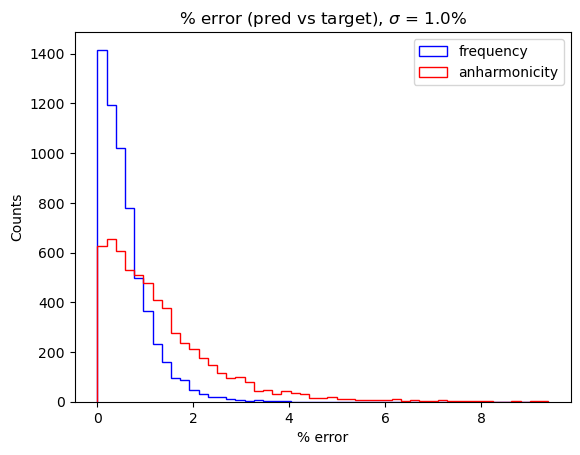

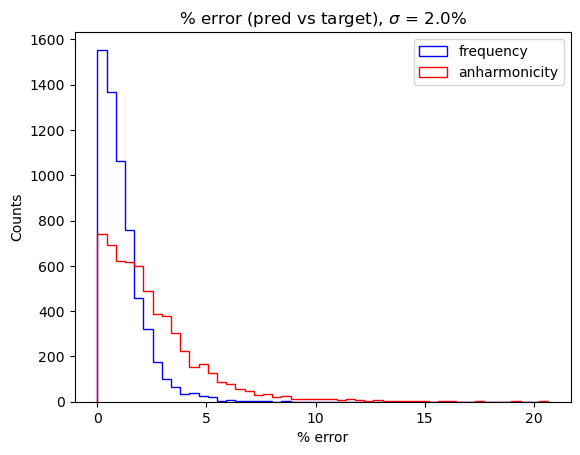

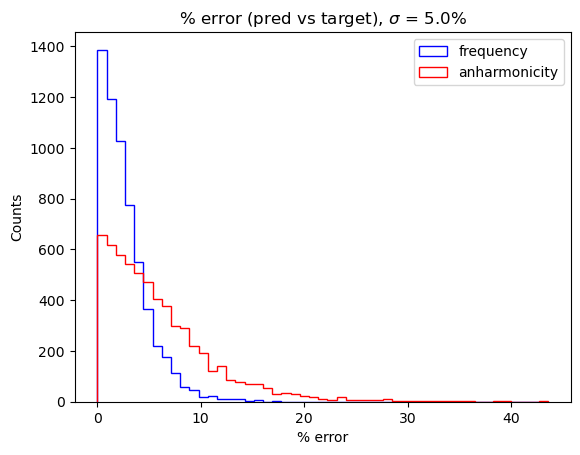

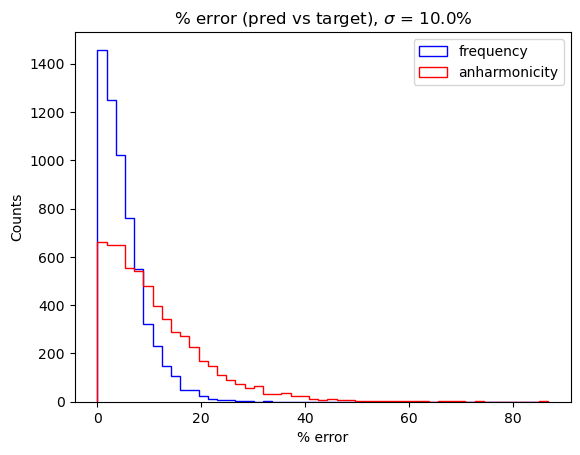

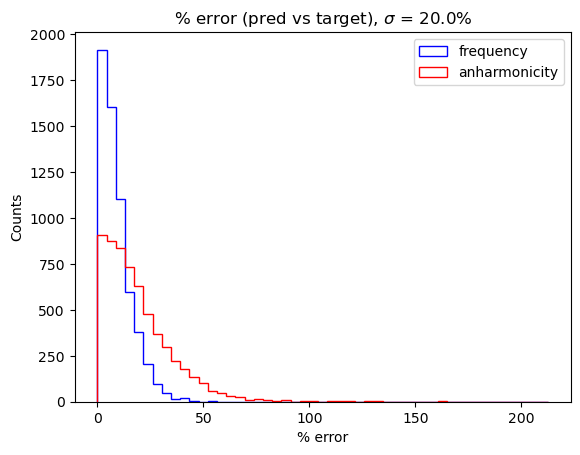

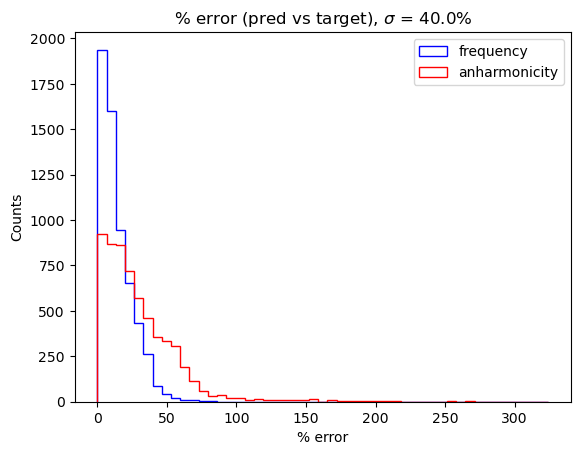

In [10]:
all_results = {}
#go through each sigma

means = []
medians= [] 

for sigma_frac in SIGMA_FRACTIONS:
    print(f'\n{"-"*70}')
    print(f'Sigma fraction: {sigma_frac} ({sigma_frac*100:.0f}% of param range)')
    print(f'{"-"*70}')

    #store the samples, index number associated with test point for that gaus, 
    #and Hamiltonian associated with the test point
    all_augmented_unscaled = []  
    all_seed_idx = []            
    all_target_Hamiltonian_scaled = []  
    
    for i, si in enumerate(seed_indices):
        #aug_unscaled = generate_augmented(seed_samples_unscaled[i], N_NOISY_PER_SEED, sigma_frac,param_ranges, is_integer_param, integer_unique_vals)
        aug_unscaled = generate_augmented_bounded(seed_samples_unscaled[i], N_NOISY_PER_SEED, sigma_frac,param_ranges, is_integer_param, integer_unique_vals)
        
        all_augmented_unscaled.append(aug_unscaled)
        all_seed_idx.extend([si] * N_NOISY_PER_SEED)
        all_target_Hamiltonian_scaled.extend([seed_Hamiltonian_scaled[i]] * N_NOISY_PER_SEED)
    
    all_augmented_unscaled = np.vstack(all_augmented_unscaled)
    all_seed_idx = np.array(all_seed_idx)
    all_target_Hamiltonian_scaled = np.array(all_target_Hamiltonian_scaled)
    
    # scale the 'noisy' params back to [0,1] for the surrogate
    all_augmented_scaled = scale_qiskit(all_augmented_unscaled)
    
    #actually run through surrogate and time it
    print(f'Running {len(all_augmented_scaled)} samples through surrogate...')
    t0 = time.time()
    with tf.device('/CPU:0'):
        predicted_Hamiltonian_scaled = surrogate.predict(all_augmented_scaled.astype('float32'), verbose=0)
    t1 = time.time()
    total_time = t1 - t0
    per_sample_us = (total_time / len(all_augmented_scaled)) * 1e6
    print(f'  Time: {total_time:.3f}s total, {per_sample_us:.1f} μs/sample')
    
    # firnd how close is surrogate prediction to the target Hamiltonian, make an error based on that
    # (MSE per sample between predicted Hamiltonian and target Hamiltonian)
    Hamiltonian_errors = np.mean((predicted_Hamiltonian_scaled - all_target_Hamiltonian_scaled) ** 2, axis=1)
    
    # unscale 
    predicted_Hamiltonian_unscaled = unscale_Hamiltonian(predicted_Hamiltonian_scaled)
    target_Hamiltonian_unscaled = unscale_Hamiltonian(all_target_Hamiltonian_scaled)
    
    # Percentage error per Hamiltonian column
    eps = 1e-15
    pct_errors = 100.0 * np.abs(predicted_Hamiltonian_unscaled - target_Hamiltonian_unscaled) / (np.abs(target_Hamiltonian_unscaled) + eps)
    mean_pct_error_per_sample = pct_errors.mean(axis=1)
    fig,ax = plt.subplots()
    bins = np.linspace(min(pct_errors[:,1]),max(pct_errors[:,1]),50)
    ax.hist(pct_errors[:,0],color = "blue",histtype='step',bins = bins,label = "frequency")
    ax.hist(pct_errors[:,1],color = "red",histtype='step',bins = bins,label = "anharmonicity")
    ax.set_title(r"% error (pred vs target), $\sigma$ = " + "{}%".format(np.round(sigma_frac*100)))
    ax.set_ylabel("Counts")
    ax.set_xlabel(r"% error")
    plt.legend()
    plt.savefig("plots/pctErr{}.png".format(np.round(sigma_frac*100)))
    
    ''' look at frequency and alpha separately '''
    # pct_errors = 100.0 * np.abs(predicted_Hamiltonian_unscaled[:,0] - target_Hamiltonian_unscaled[:,0]) / (np.abs(target_Hamiltonian_unscaled[:,0]) + eps)
    # mean_pct_error_per_sample = pct_errors.mean()#(axis=1)
    # means.append(mean_pct_error_per_sample)
    # medians.append(np.median(pct_errors))
    
    all_results[sigma_frac] = {
        'augmented_unscaled': all_augmented_unscaled,
        'augmented_scaled': all_augmented_scaled,
        'seed_idx': all_seed_idx,
        'predicted_Hamiltonian_scaled': predicted_Hamiltonian_scaled,
        'predicted_Hamiltonian_unscaled': predicted_Hamiltonian_unscaled,
        'target_Hamiltonian_unscaled': target_Hamiltonian_unscaled,
        'Hamiltonian_errors_mse': Hamiltonian_errors,
        'pct_errors': pct_errors,
        'mean_pct_per_sample': mean_pct_error_per_sample,
        'total_time': total_time,
        'per_sample_us': per_sample_us,
    }
    
    print(f'  Mean % error: {mean_pct_error_per_sample.mean():.6f}%')
    print(f'  Median % error: {np.median(mean_pct_error_per_sample):.6f}%')
    print(f'  90th percentile: {np.percentile(mean_pct_error_per_sample, 90):.2f}%')
    print(f'  Max % error: {mean_pct_error_per_sample.max():.2f}%')



## Visualize the results

First see how 'accuracy' scales with sigma, although this isnt really accurate because it compares values far away from the center points to the ones close, so we expect points from the higher sigma gaussian to do worse because they are further from the center point that we compare the Hamiltonian values to

In [11]:
# ================================================================
# Nearest-training-point distance for every augmented sample.
#
# We work in the scaled [0,1] parameter space so each of the 3 Qiskit
# Metal params contributes equally (otherwise the param with the largest
# raw range would dominate the distance).  Euclidean distance is used
# (RMS would give an identical ranking, just divided by sqrt(n_params)).
# ================================================================

X_train_scaled = np.asarray(X_train).astype('float64')  # already in [0,1]

def nearest_train_distance(points_scaled, train_scaled=X_train_scaled):
    # Euclidean distance from each point to its closest training sample,
    # computed in the scaled [0,1] space.
    diff = points_scaled[:, None, :] - train_scaled[None, :, :]
    d = np.sqrt((diff ** 2).sum(axis=-1))
    return d.min(axis=1)

for sigma_frac in SIGMA_FRACTIONS:
    r = all_results[sigma_frac]
    r['nn_dist'] = nearest_train_distance(r['augmented_scaled'].astype('float64'))

# Quick summary so we can eyeball the distance distribution per sigma
print(f'{"Sigma %":>8s} {"min NN":>10s} {"med NN":>10s} {"mean NN":>10s} {"max NN":>10s}')
print('-' * 52)
for sigma_frac in SIGMA_FRACTIONS:
    d = all_results[sigma_frac]['nn_dist']
    print(f'{sigma_frac*100:8.0f} {d.min():10.4f} {np.median(d):10.4f} {d.mean():10.4f} {d.max():10.4f}')


 Sigma %     min NN     med NN    mean NN     max NN
----------------------------------------------------
       1     0.0023     0.0261     0.0267     0.0635
       2     0.0017     0.0266     0.0280     0.0827
       5     0.0020     0.0400     0.0437     0.1733
      10     0.0032     0.0519     0.0623     0.3520
      20     0.0019     0.0697     0.1030     0.3998
      40     0.0037     0.1197     0.1456     0.4274


In [12]:
# #plot error vs sigma to see where the surrogate starts to fail
# sigmas = sorted(all_results.keys())
# # medians = [np.median(all_results[s]['mean_pct_per_sample']) for s in sigmas]
# # means = [all_results[s]['mean_pct_per_sample'].mean() for s in sigmas]
# # maxes = [all_results[s]['mean_pct_per_sample'].max() for s in sigmas]

# fig, ax = plt.subplots(figsize=(10, 6))
# ax.plot([s*100 for s in sigmas], medians, 'o-', label='Median', linewidth=2)
# ax.plot([s*100 for s in sigmas], means, 's-', label='Mean', linewidth=2)
# ax.set_xlabel('Sigma (% of parameter range)')
# ax.set_ylabel(r'Mean % Error in Predicted $f_q$ values')
# ax.set_title(r'Surrogate Model Stress Test: Error vs Noise Level ($f_q$ only)')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# #plt.savefig('plots/surrogate_stress_test_error_vs_sigma.pdf')
# plt.show()

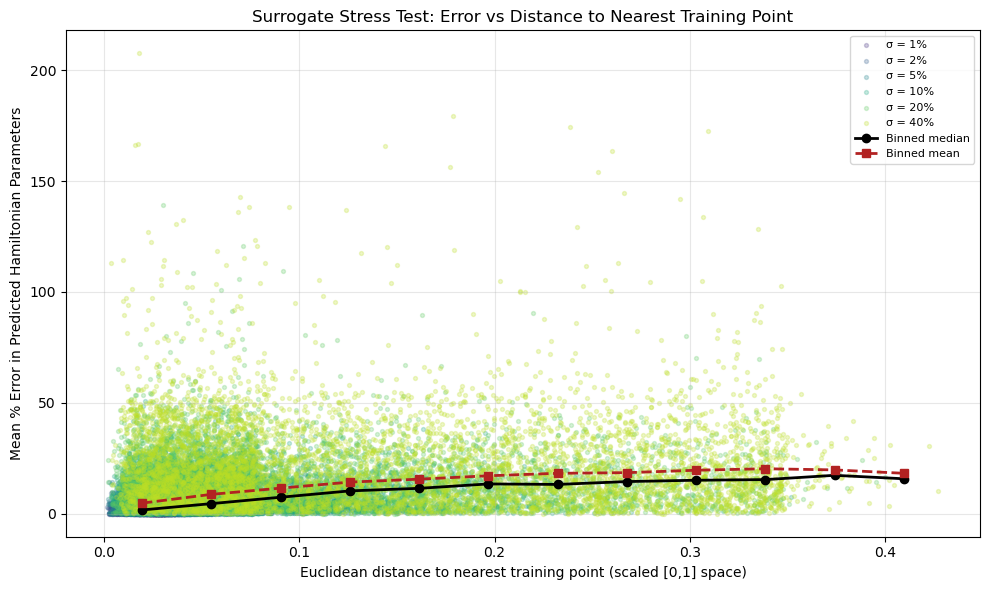

     Dist bin (scaled)      N   Median %     Mean %     90th %      Max %
------------------------------------------------------------------------
        [0.002, 0.023]   7200      2.146      5.143     12.692    207.597
        [0.023, 0.032]   7200      1.231      4.170     11.027    139.433
        [0.032, 0.050]   7200      2.588      6.578     18.068    132.433
        [0.050, 0.089]   7200      6.052     10.257     24.533    143.029
        [0.089, 0.427]   7200     11.861     16.213     35.773    179.373


In [13]:
# Plot error vs nearest-training-point distance (in scaled [0,1] param space).
# This is a more honest 'accuracy vs extrapolation' picture than plotting
# against sigma: two samples from different sigmas can land the same
# distance from the nearest training point, and *that* is what determines
# how hard the surrogate has to extrapolate.

sigmas = sorted(all_results.keys())

# Flatten everything across all sigmas
all_nn = np.concatenate([all_results[s]['nn_dist'] for s in sigmas])
all_err = np.concatenate([all_results[s]['mean_pct_per_sample'] for s in sigmas])
all_sig = np.concatenate([np.full(len(all_results[s]['nn_dist']), s) for s in sigmas])

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter, colored by sigma
colors_sigma = plt.cm.viridis(np.linspace(0.15, 0.9, len(sigmas)))
for i, s in enumerate(sigmas):
    mask = all_sig == s
    ax.scatter(all_nn[mask], all_err[mask], s=8, alpha=0.25,
               color=colors_sigma[i], label=f'σ = {s*100:.0f}%')

# Binned mean + median curves so the trend is visible through the scatter
n_bins = 12
bin_edges = np.linspace(all_nn.min(), all_nn.max(), n_bins + 1)
bin_centers, bin_medians, bin_means = [], [], []
for k in range(n_bins):
    in_bin = (all_nn >= bin_edges[k]) & (all_nn < bin_edges[k + 1])
    if in_bin.sum() < 3:
        continue
    bin_centers.append(0.5 * (bin_edges[k] + bin_edges[k + 1]))
    bin_medians.append(np.median(all_err[in_bin]))
    bin_means.append(all_err[in_bin].mean())

ax.plot(bin_centers, bin_medians, 'o-', color='black', linewidth=2,
        markersize=6, label='Binned median')
ax.plot(bin_centers, bin_means, 's--', color='firebrick', linewidth=2,
        markersize=6, label='Binned mean')

ax.set_xlabel('Euclidean distance to nearest training point (scaled [0,1] space)')
ax.set_ylabel('Mean % Error in Predicted Hamiltonian Parameters')
ax.set_title('Surrogate Stress Test: Error vs Distance to Nearest Training Point')
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/surrogate_stress_test_error_vs_nn_distance.pdf')
plt.show()

# Table: binned stats by NN-distance quantile
n_qbins = 5
q_edges = np.quantile(all_nn, np.linspace(0, 1, n_qbins + 1))
print(f'{"Dist bin (scaled)":>22s} {"N":>6s} {"Median %":>10s} {"Mean %":>10s} {"90th %":>10s} {"Max %":>10s}')
print('-' * 72)
for k in range(n_qbins):
    lo, hi = q_edges[k], q_edges[k + 1]
    in_bin = (all_nn >= lo) & (all_nn <= hi if k == n_qbins - 1 else all_nn < hi)
    if in_bin.sum() == 0:
        continue
    sub = all_err[in_bin]
    label = f'[{lo:.3f}, {hi:.3f}]'
    print(f'{label:>22s} {in_bin.sum():6d} {np.median(sub):10.3f} {sub.mean():10.3f} '
          f'{np.percentile(sub, 90):10.3f} {sub.max():10.3f}')


In [14]:
# timing summary
total_samples = sum(len(all_results[s]['augmented_scaled']) for s in sigmas)
total_time = sum(all_results[s]['total_time'] for s in sigmas)
avg_us = (total_time / total_samples) * 1e6

print(f'Total samples across all sigmas: {total_samples}')
print(f'Total surrogate inference time:  {total_time:.3f}s')
print(f'Average speed:                   {avg_us:.1f} μs/sample')
print()
print('For comparison, a single Ansys HFSS simulation takes ~2 minutes.')

Total samples across all sigmas: 36000
Total surrogate inference time:  1.576s
Average speed:                   43.8 μs/sample

For comparison, a single Ansys HFSS simulation takes ~2 minutes.


## Pick Best Candidates for Ansys Validation

In [15]:
# For each sigma level, pick 10 RANDOM candidates (not best — we want unbiased samples)

N_RANDOM = 15  # how many random candidates to pick per sigma

random_candidates = {}
for sigma_frac in SIGMA_FRACTIONS:
    r = all_results[sigma_frac]
    # Pick random indices instead of sorting by error
    rand_idx = np.random.choice(len(r['Hamiltonian_errors_mse']), size=N_RANDOM, replace=False)
    
    random_candidates[sigma_frac] = {
        'indices': rand_idx,
        'params_unscaled': r['augmented_unscaled'][rand_idx],
        'params_scaled': r['augmented_scaled'][rand_idx],
        'predicted_Hamiltonian_unscaled': r['predicted_Hamiltonian_unscaled'][rand_idx],
        'target_Hamiltonian_unscaled': r['target_Hamiltonian_unscaled'][rand_idx],
        'mean_pct_error': r['mean_pct_per_sample'][rand_idx],
        'seed_idx': r['seed_idx'][rand_idx],
    }

print(f'Selected {N_RANDOM} random candidates per sigma level ({N_RANDOM * len(SIGMA_FRACTIONS)} total)')


Selected 15 random candidates per sigma level (90 total)


In [16]:
# Print the random candidates for each sigma level
for sigma_frac in SIGMA_FRACTIONS:
    rc = random_candidates[sigma_frac]
    print(f'\n{"-"*80}')
    print(f'RANDOM {len(rc["indices"])} CANDIDATES — Sigma = {sigma_frac*100:.0f}% of param range')
    print(f'{"-"*80}')
    
    for rank in range(len(rc['indices'])):
        print(f'\n--- Sample {rank+1} (mean Hamiltonian error: {rc["mean_pct_error"][rank]:.2f}%) ---')
        print(f'  Seed test sample index: {rc["seed_idx"][rank]}')
        
        print(f'  Qiskit Metal params (for Ansys simulation):')
        for j, name in enumerate(qiskit_param_names):
            short = name.replace('design_options.', '')
            val = rc['params_unscaled'][rank, j]
            if is_integer_param[j]:
                print(f'    {short:30s}  {int(round(val))}')
            else:
                print(f'    {short:30s}  {val}')
        
        print(f'  Surrogate predicted Hamiltonian:')
        for j, name in enumerate(Hamiltonian_column_names):
            short = name.split('.')[-1] if '.' in name else name
            print(f'    {short:30s}  {rc["predicted_Hamiltonian_unscaled"][rank, j]:.6e}')
        
        print(f'  Target Hamiltonian (from seed test sample):')
        for j, name in enumerate(Hamiltonian_column_names):
            short = name.split('.')[-1] if '.' in name else name
            print(f'    {short:30s}  {rc["target_Hamiltonian_unscaled"][rank, j]:.6e}')



--------------------------------------------------------------------------------
RANDOM 15 CANDIDATES — Sigma = 1% of param range
--------------------------------------------------------------------------------

--- Sample 1 (mean Hamiltonian error: 0.74%) ---
  Seed test sample index: 68
  Qiskit Metal params (for Ansys simulation):
    connection_pads.readout.claw_length  0.00012937156039239515
    connection_pads.readout.ground_spacing  9.875196874699488e-06
    cross_length                    0.00014804648293801565
  Surrogate predicted Hamiltonian:
    qubit_frequency_GHz             5.552522e+00
    anharmonicity_MHz               -2.928366e+02
  Target Hamiltonian (from seed test sample):
    qubit_frequency_GHz             5.526951e+00
    anharmonicity_MHz               -2.898655e+02

--- Sample 2 (mean Hamiltonian error: 1.32%) ---
  Seed test sample index: 123
  Qiskit Metal params (for Ansys simulation):
    connection_pads.readout.claw_length  0.00011958199221731353
    c

## Exporting Best Candidates for Firas to Simulate

In [17]:
# Save a CSV with all the random candidates for Firas to simulate in Ansys
export_rows = []
for sigma_frac in SIGMA_FRACTIONS:
    rc = random_candidates[sigma_frac]
    for rank in range(len(rc['indices'])):
        row = {
            'sigma_for_gauss': sigma_frac * 100,
            'sample_number': rank + 1,
            'test_set_index_as_gauss_mean': rc['seed_idx'][rank],
            'avg_percent_err_in_Hamiltonian': rc['mean_pct_error'][rank],
            'surrogate_inference_us': all_results[sigma_frac]['per_sample_us'],
        }
        #qiskit metal params
        for j, name in enumerate(qiskit_param_names):
            val = rc['params_unscaled'][rank, j]
            row[f'{name}'] = val
        #surrogate predicted Hamiltonian params
        for j, name in enumerate(Hamiltonian_column_names):
            short = name.split('.')[-1] if '.' in name else name
            row[f'surrogate_pred_{short}'] = rc['predicted_Hamiltonian_unscaled'][rank, j]
        #target Hamiltonian params
        for j, name in enumerate(Hamiltonian_column_names):
            short = name.split('.')[-1] if '.' in name else name
            row[f'target_{short}'] = rc['target_Hamiltonian_unscaled'][rank, j]
        export_rows.append(row)

df_export = pd.DataFrame(export_rows)
csv_path = 'random_candidates_for_ansys_validation_v3.csv'
df_export.to_csv(csv_path, index=False, float_format='%.6g')
print(f'Saved {len(df_export)} random candidates to {csv_path} ({N_RANDOM} per sigma x {len(SIGMA_FRACTIONS)} sigmas)')
display(df_export)


Saved 90 random candidates to random_candidates_for_ansys_validation_v3.csv (15 per sigma x 6 sigmas)


,sigma_for_gauss,sample_number,test_set_index_as_gauss_mean,avg_percent_err_in_Hamiltonian,surrogate_inference_us,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length,surrogate_pred_qubit_frequency_GHz,surrogate_pred_anharmonicity_MHz,target_qubit_frequency_GHz,target_anharmonicity_MHz
0,1.0,1,68,0.743841,64.449112,0.000129,0.000010,0.000148,5.552522,-292.836639,5.526951,-289.865466
1,1.0,2,123,1.324855,64.449112,0.000120,0.000010,0.000147,5.571598,-295.128143,5.526511,-289.813276
2,1.0,3,27,3.323277,64.449112,0.000248,0.000005,0.000279,3.954472,-137.716324,4.034047,-144.468737
3,1.0,4,156,0.107992,64.449112,0.000200,0.000004,0.000270,4.104348,-149.615082,4.103134,-149.894473
4,1.0,5,284,0.828752,64.449112,0.000099,0.000009,0.000207,4.606374,-193.109558,4.583125,-190.913610
...,...,...,...,...,...,...,...,...,...,...,...,...
85,40.0,11,71,28.104669,41.008472,0.000079,0.000004,0.000249,4.259392,-162.432541,5.256166,-258.837783
86,40.0,12,82,24.315100,41.008472,0.000170,0.000005,0.000179,5.000821,-231.415451,4.373972,-172.313784
87,40.0,13,81,0.793817,41.008472,0.000310,0.000008,0.000370,3.426679,-101.043343,3.402678,-100.159643
88,40.0,14,168,21.714333,41.008472,0.000081,0.000010,0.000218,4.556965,-188.713760,4.035676,-144.595329


In [18]:
# === 20 linearly spaced samples along a single Gaussian at 40% sigma ===
# Pick one seed sample, then create points that walk linearly from the center
# out to 2*sigma in a random direction through the 3D parameter space.
# This gives Firas a clean sweep from "close to training data" to "far away"

np.random.seed(123)

# Pick one seed (use the most popular one from earlier, or just the first)
linear_seed_idx = seed_indices[0]
linear_seed_pos = 0
linear_seed_unscaled = seed_samples_unscaled[linear_seed_pos].copy()
linear_seed_Hamiltonian_scaled = seed_Hamiltonian_scaled[linear_seed_pos]

sigma_frac_linear = 0.40
sigmas_per_param = sigma_frac_linear * param_ranges

# Pick a random direction in the full n-dimensional parameter space
direction = np.random.randn(len(qiskit_param_names))
direction = direction / np.linalg.norm(direction)  # unit vector

# Scale direction by each param's sigma so we move proportionally
scaled_direction = direction * sigmas_per_param

# 20 linearly spaced points from -2*sigma to +2*sigma along this direction
t_values = np.linspace(-2.0, 2.0, 20)
linear_samples_unscaled = np.array([linear_seed_unscaled + t * scaled_direction for t in t_values])

# Scale and run through surrogate
linear_samples_scaled = scale_qiskit(linear_samples_unscaled)
with tf.device('/CPU:0'):
    linear_pred_Hamiltonian_scaled = surrogate.predict(linear_samples_scaled.astype('float32'), verbose=0)
linear_pred_Hamiltonian_unscaled = unscale_Hamiltonian(linear_pred_Hamiltonian_scaled)

# Target Hamiltonian (from the seed)
target_Hamiltonian_unscaled = unscale_Hamiltonian(np.array([linear_seed_Hamiltonian_scaled]))[0]

# Build CSV
export_rows = []
for i in range(20):
    row = {
        'sample_number': i + 1,
        'sigma_multiplier': t_values[i],
        'sigma_for_gauss': sigma_frac_linear * 100,
        'test_set_index_as_gauss_mean': linear_seed_idx,
    }
    # Qiskit Metal params
    for j, name in enumerate(qiskit_param_names):
        row[f'{name}'] = linear_samples_unscaled[i, j]
    # Surrogate predicted Hamiltonian params
    for j, name in enumerate(Hamiltonian_column_names):
        short = name.split('.')[-1] if '.' in name else name
        row[f'surrogate_pred_{short}'] = linear_pred_Hamiltonian_unscaled[i, j]
    # Target Hamiltonian params
    for j, name in enumerate(Hamiltonian_column_names):
        short = name.split('.')[-1] if '.' in name else name
        row[f'target_{short}'] = target_Hamiltonian_unscaled[j]
    export_rows.append(row)

df_linear = pd.DataFrame(export_rows)
csv_path = 'linear_sweep_40pct_sigma_for_ansys.csv'
df_linear.to_csv(csv_path, index=False, float_format='%.6g')
print(f'Saved {len(df_linear)} linearly spaced samples to {csv_path}')
print(f'Seed test index: {linear_seed_idx}')
print(f'Direction walks from -2σ to +2σ along a random direction in param space')
print(f'σ = 40% of each param range')
print()
print(f'sigma_multiplier column: -2.0 = far one side, 0.0 = at the seed, +2.0 = far other side')
display(df_linear)

Saved 20 linearly spaced samples to linear_sweep_40pct_sigma_for_ansys.csv
Seed test index: 97
Direction walks from -2σ to +2σ along a random direction in param space
σ = 40% of each param range

sigma_multiplier column: -2.0 = far one side, 0.0 = at the seed, +2.0 = far other side


/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


,sample_number,sigma_multiplier,sigma_for_gauss,test_set_index_as_gauss_mean,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length,surrogate_pred_qubit_frequency_GHz,surrogate_pred_anharmonicity_MHz,target_qubit_frequency_GHz,target_anharmonicity_MHz
0,1,-2.000000,40.0,97,0.000311,0.000002,0.000260,4.434668,-184.092514,3.760796,-124.143101
1,2,-1.789474,40.0,97,0.000291,0.000002,0.000265,4.351963,-175.653015,3.760796,-124.143101
2,3,-1.578947,40.0,97,0.000271,0.000003,0.000271,4.271392,-167.783203,3.760796,-124.143101
3,4,-1.368421,40.0,97,0.000251,0.000003,0.000276,4.190782,-159.911697,3.760796,-124.143101
4,5,-1.157895,40.0,97,0.000231,0.000003,0.000281,4.109633,-152.016403,3.760796,-124.143101
5,6,-0.947368,40.0,97,0.000210,0.000004,0.000286,4.028484,-144.121094,3.760796,-124.143101
6,7,-0.736842,40.0,97,0.000190,0.000004,0.000292,3.961261,-138.273239,3.760796,-124.143101
7,8,-0.526316,40.0,97,0.000170,0.000004,0.000297,3.903945,-134.241791,3.760796,-124.143101
8,9,-0.315789,40.0,97,0.000150,0.000005,0.000302,3.846962,-130.221878,3.760796,-124.143101
9,10,-0.105263,40.0,97,0.000130,0.000005,0.000307,3.789979,-126.201912,3.760796,-124.143101


In [19]:
# Summary of what was exported
print(f'Total candidates for Firas: {len(df_export)}')
print(f'  {N_RANDOM} random samples per sigma level')
print(f'  Sigma levels: {[f"{s*100:.0f}%" for s in SIGMA_FRACTIONS]}')
print(f'\nThese are RANDOM samples (not cherry-picked best ones)')
print(f'so the Ansys results will give an unbiased picture of surrogate accuracy.')


Total candidates for Firas: 90
  15 random samples per sigma level
  Sigma levels: ['1%', '2%', '5%', '10%', '20%', '40%']

These are RANDOM samples (not cherry-picked best ones)
so the Ansys results will give an unbiased picture of surrogate accuracy.


## Per-Sigma Scatter Plots

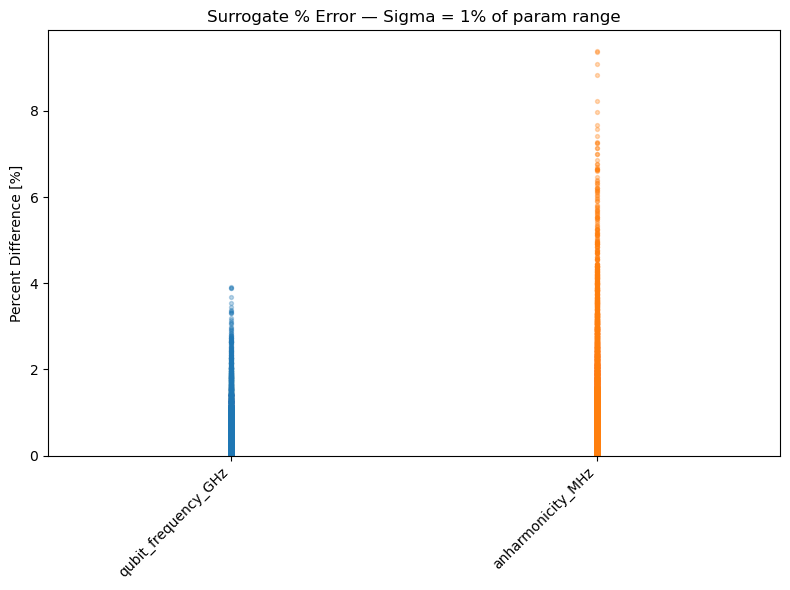

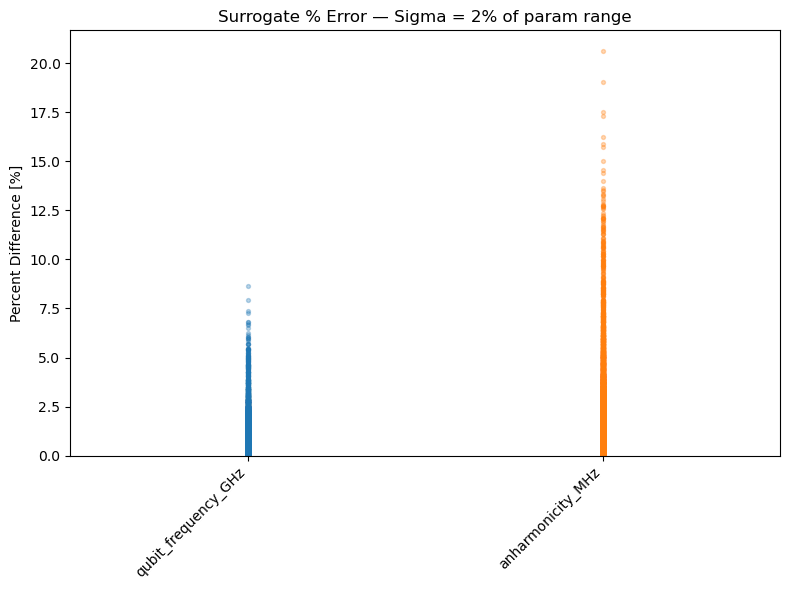

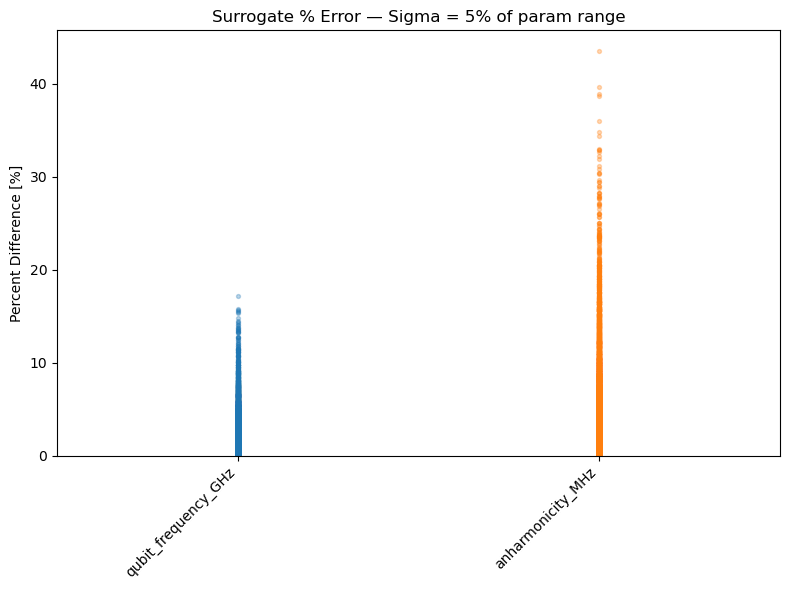

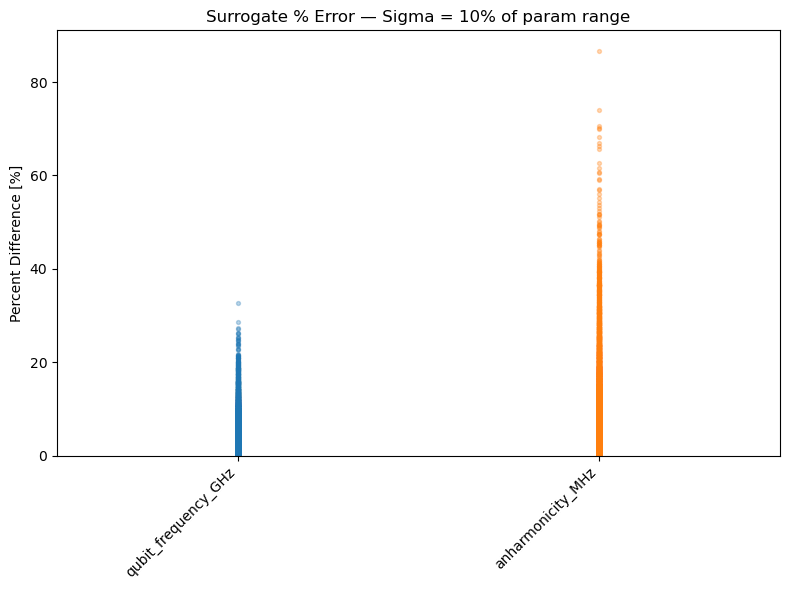

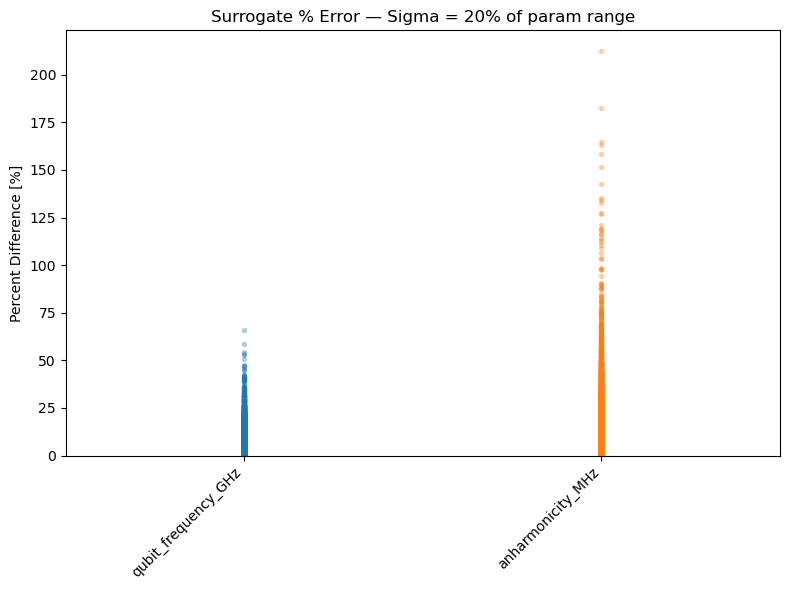

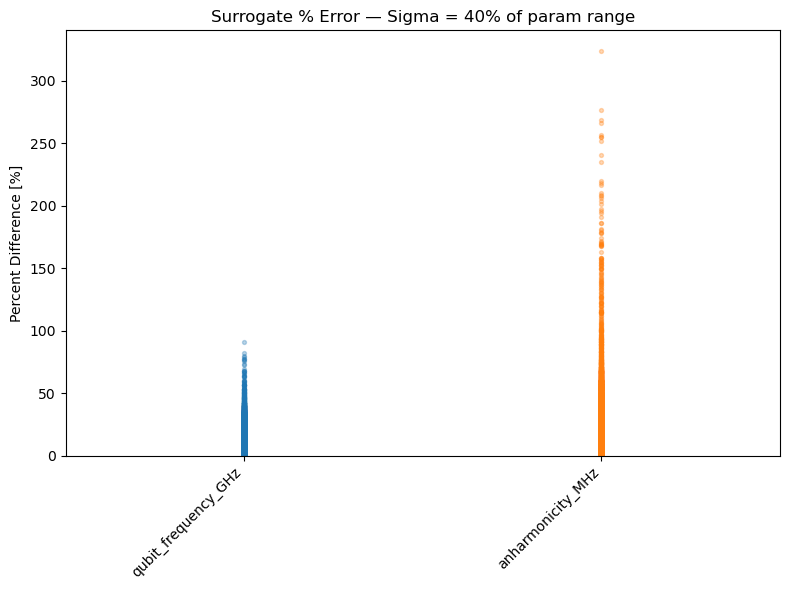

In [20]:
# for each sigma, scatter plot of % error per Hamiltonian column
short_Hamiltonian_names = [c.split('.')[-1] if '.' in c else c for c in Hamiltonian_column_names]
n_Hamiltonian = len(Hamiltonian_column_names)

for sigma_frac in SIGMA_FRACTIONS:
    r = all_results[sigma_frac]
    fig, ax = plt.subplots(figsize=(8, 6))
    for j in range(n_Hamiltonian):
        col_pct = r['pct_errors'][:, j]
        ax.scatter(np.full(len(col_pct), j), col_pct, s=8, alpha=0.3)
    ax.set_xticks(range(n_Hamiltonian))
    ax.set_xticklabels(short_Hamiltonian_names, rotation=45, ha='right')
    ax.set_ylabel('Percent Difference [%]')
    ax.set_title(f'Surrogate % Error — Sigma = {sigma_frac*100:.0f}% of param range')
    ax.set_ylim(0, None)
    ax.margins(y=0)
    ax.set_xlim(-0.5, n_Hamiltonian - 0.5)
    plt.tight_layout()
    plt.savefig(f'plots/surrogate_stress_sigma_{int(sigma_frac*100)}_pct_scatter.pdf')
    plt.show()

## plot in 3d the gaussians to get a feeling for their shapes/ranges

Top 4 test vals by frequency in best candidates:
  Seed test idx 139: 1 best candidates
  Seed test idx 68: 1 best candidates
  Seed test idx 247: 3 best candidates


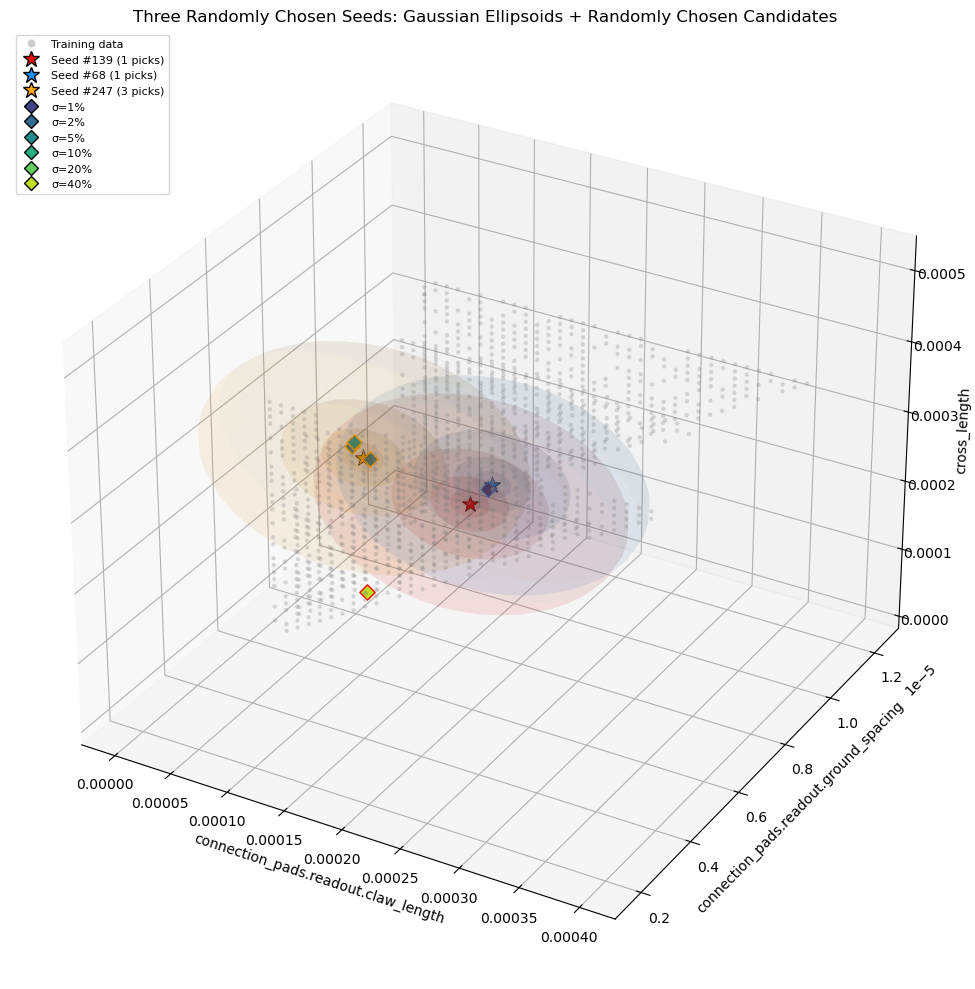

In [21]:
from mpl_toolkits.mplot3d import Axes3D
from collections import Counter
from matplotlib.lines import Line2D
import random

cont_indices = [j for j in range(len(qiskit_param_names)) if not is_integer_param[j]]
if len(cont_indices) >= 3:
    p0, p1, p2 = cont_indices[0], cont_indices[1], cont_indices[2]
else:
    p0, p1, p2 = 0, 1, 2

axis_names = [
    qiskit_param_names[p0].replace('design_options.', ''),
    qiskit_param_names[p1].replace('design_options.', ''),
    qiskit_param_names[p2].replace('design_options.', ''),
]

def draw_ellipsoid(ax, center, sigmas, color, alpha=0.15):
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 20)
    x = center[0] + sigmas[0] * np.outer(np.cos(u), np.sin(v))
    y = center[1] + sigmas[1] * np.outer(np.sin(u), np.sin(v))
    z = center[2] + sigmas[2] * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(x, y, z, color=color, alpha=alpha, linewidth=0)

colors_sigma = plt.cm.viridis(np.linspace(0.2, 0.9, len(SIGMA_FRACTIONS)))
seed_idx_to_pos = {si: i for i, si in enumerate(seed_indices)}

# count how many of the best 10 per sigma came from each test value
seed_counts = Counter()
seed_to_best = {}
for sigma_frac in SIGMA_FRACTIONS:
    bc = random_candidates[sigma_frac]
    for rank in range(10):
        sid = bc['seed_idx'][rank]
        seed_counts[sid] += 1
        if sid not in seed_to_best:
            seed_to_best[sid] = []
        seed_to_best[sid].append({
            'sigma_frac': sigma_frac,
            'rank': rank,
            'params': bc['params_unscaled'][rank],
        })

# pick top 4 test values to plot gauss around
top_4_seeds = random.sample(list(seed_counts.keys()), 3)
print(f'Top 4 test vals by frequency in best candidates:')
for sid in top_4_seeds:
    print(f'  Seed test idx {sid}: {seed_counts[sid]} best candidates')

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# training data 
ax.scatter(X_train_unscaled[:, p0], X_train_unscaled[:, p1], X_train_unscaled[:, p2],
           c='gray', s=5, alpha=0.2, label='Training data')

#plot the best vals
seed_colors = ['red', 'dodgerblue', 'orange', 'lime']
seed_markers = ['*', '*', '*']

for seed_rank, top_seed in enumerate(top_4_seeds):
    pos = seed_idx_to_pos[top_seed]
    sc = seed_colors[seed_rank]

    # test val (star)
    ax.scatter(seed_samples_unscaled[pos, p0],
               seed_samples_unscaled[pos, p1],
               seed_samples_unscaled[pos, p2],
               c=sc, s=150, marker='*', edgecolors='black', linewidths=0.5, zorder=5)

    # Ellipsoids at each sigma
    center = [seed_samples_unscaled[pos, p0],
              seed_samples_unscaled[pos, p1],
              seed_samples_unscaled[pos, p2]]
    for si_frac, sigma_frac in enumerate(SIGMA_FRACTIONS):
        sigmas_3d = [sigma_frac * param_ranges[p0],
                     sigma_frac * param_ranges[p1],
                     sigma_frac * param_ranges[p2]]
        draw_ellipsoid(ax, center, sigmas_3d, sc, alpha=0.05)

    # Best candidates from thistest val, color-coded by sigma
    for entry in seed_to_best[top_seed]:
        si_frac = SIGMA_FRACTIONS.index(entry['sigma_frac'])
        params = entry['params']
        ax.scatter(params[p0], params[p1], params[p2],
                   c=[colors_sigma[si_frac]], s=60, marker='D',
                   edgecolors=sc, linewidths=1.0, zorder=10)

# legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=6, alpha=0.4, label='Training data'),
]
for i, (sid, sc) in enumerate(zip(top_4_seeds, seed_colors)):
    legend_elements.append(
        Line2D([0], [0], marker='*', color='w', markerfacecolor=sc,
               markeredgecolor='black', markersize=12,
               label=f'Seed #{sid} ({seed_counts[sid]} picks)'))
for si_frac, sigma_frac in enumerate(SIGMA_FRACTIONS):
    legend_elements.append(
        Line2D([0], [0], marker='D', color='w', markerfacecolor=colors_sigma[si_frac],
               markeredgecolor='black', markersize=7,
               label=f'σ={sigma_frac*100:.0f}%'))

ax.set_xlabel(axis_names[0])
ax.set_ylabel(axis_names[1])
ax.set_zlabel(axis_names[2])
ax.set_title('Three Randomly Chosen Seeds: Gaussian Ellipsoids + Randomly Chosen Candidates')
ax.legend(handles=legend_elements, loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('plots/surrogate_stress_3d_random4_seeds.pdf')
plt.show()

In [22]:
for entry in seed_to_best[top_seed]:
    si_frac = SIGMA_FRACTIONS.index(entry['sigma_frac'])
    params = entry['params']
    print(si_frac)
    print(params[p0], params[p1], params[p2])

1
0.00015550523209293678 4.1195117255623056e-06 0.0003799177725545763
1
0.00013642848276245747 4.275299782931202e-06 0.0003837639889232443
2
0.00013736244604709455 4.328767015157263e-06 0.0003883385408636928


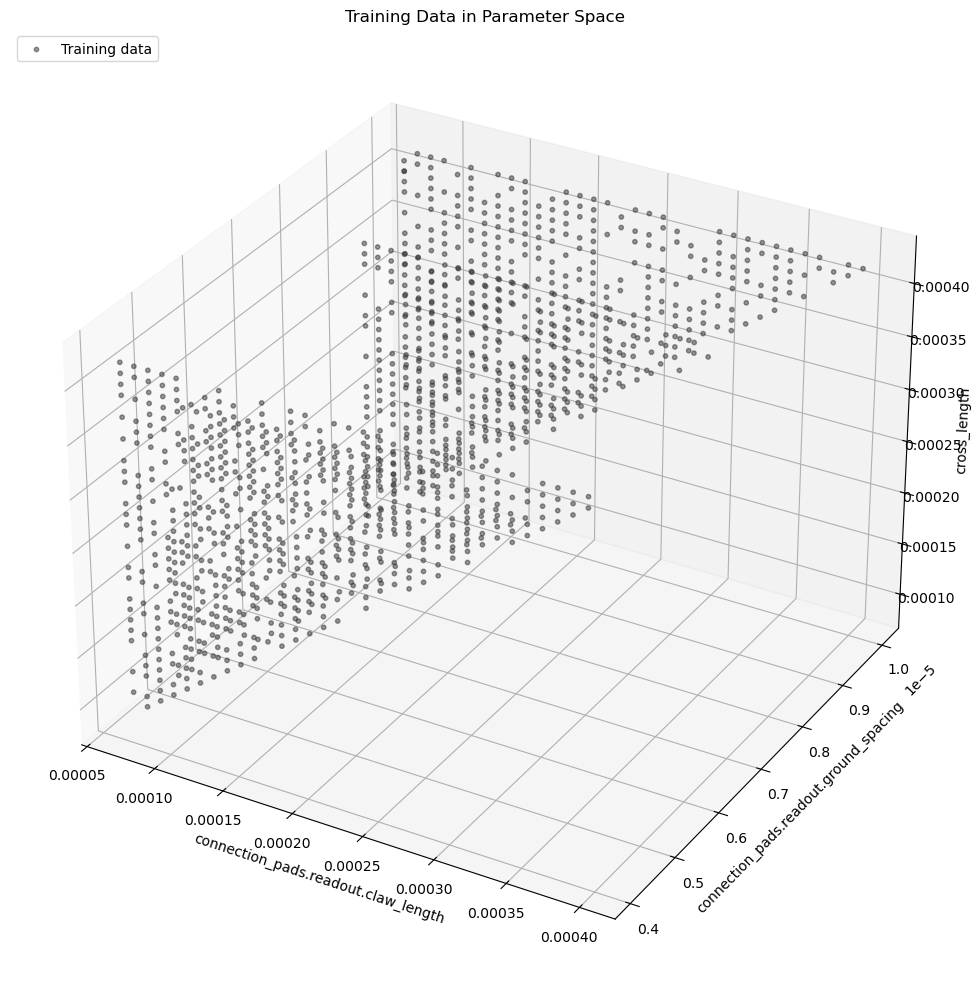

In [23]:
cont_indices = [j for j in range(len(qiskit_param_names)) if not is_integer_param[j]]
if len(cont_indices) >= 3:
    p0, p1, p2 = cont_indices[0], cont_indices[1], cont_indices[2]
else:
    p0, p1, p2 = 0, 1, 2

axis_names = [
    qiskit_param_names[p0].replace('design_options.', ''),
    qiskit_param_names[p1].replace('design_options.', ''),
    qiskit_param_names[p2].replace('design_options.', ''),
]

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_train_unscaled[:, p0], X_train_unscaled[:, p1], X_train_unscaled[:, p2],
           c='#333333', s=10, alpha=0.5, label='Training data')

ax.set_xlabel(axis_names[0])
ax.set_ylabel(axis_names[1])
ax.set_zlabel(axis_names[2])
ax.set_title('Training Data in Parameter Space')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('plots/training_data_3d.pdf')
plt.show()

# Ansys results

In [24]:
df = pd.read_csv('best_candidates_for_ansys_validation-with_Ansys.csv')

cap_names = ['cross_to_ground', 'claw_to_ground', 'cross_to_claw',
             'cross_to_cross', 'claw_to_claw', 'ground_to_ground']
eps = 1e-15

# Compute % errors: Ansys vs surrogate, and Ansys vs target
for cap in cap_names:
    df[f'pct_ansys_vs_surrogate_{cap}'] = 100 * abs(df[f'ansys_{cap}'] - df[f'surrogate_pred_{cap}']) / (abs(df[f'ansys_{cap}']) + eps)
    df[f'pct_ansys_vs_target_{cap}'] = 100 * abs(df[f'ansys_{cap}'] - df[f'target_{cap}']) / (abs(df[f'ansys_{cap}']) + eps)

# Mean % error across all cap columns per row
df['mean_pct_ansys_vs_surrogate'] = df[[f'pct_ansys_vs_surrogate_{c}' for c in cap_names]].mean(axis=1)
df['mean_pct_ansys_vs_target'] = df[[f'pct_ansys_vs_target_{c}' for c in cap_names]].mean(axis=1)

sigmas = sorted(df['sigma_for_gauss'].unique())

# Compute NN distance (scaled [0,1] Euclidean) for every row in the Ansys df.
# The CSV stores the UNSCALED Qiskit params - we scale them first using the
# same scalers the surrogate was trained with.
def _match_param_col(df_cols, qname):
    # prefer exact, then 'param_' prefix, then endswith, then short-name exact
    short = qname.split('.')[-1]
    for cand in (qname, f'param_{qname}'):
        if cand in df_cols:
            return cand
    endings = [c for c in df_cols if c.endswith(qname) or c.endswith('.' + short)]
    if endings:
        return endings[0]
    shorts = [c for c in df_cols if c == short or c == f'param_{short}']
    if shorts:
        return shorts[0]
    return None

df_cols = list(df.columns)
param_order_for_scaling = [_match_param_col(df_cols, name) for name in qiskit_param_names]

if all(c is not None for c in param_order_for_scaling):
    df_params_unscaled = df[param_order_for_scaling].to_numpy(dtype='float64')
    df_params_scaled = scale_qiskit(df_params_unscaled)
    df['nn_dist'] = nearest_train_distance(df_params_scaled)
    print(f'Matched param columns in CSV: {param_order_for_scaling}')
else:
    print('WARNING: could not match all param_cols in CSV to qiskit_param_names.')
    print(f'  qiskit_param_names = {qiskit_param_names}')
    print(f'  df columns containing "param": {[c for c in df_cols if "param" in c.lower() or any(q.split(".")[-1] in c for q in qiskit_param_names)]}')
    df['nn_dist'] = np.nan

print(f'Ansys-df nn_dist:  min={df["nn_dist"].min():.4f}  '
      f'median={df["nn_dist"].median():.4f}  max={df["nn_dist"].max():.4f}')


Matched param columns in CSV: ['param_connection_pads.readout.claw_length', 'param_connection_pads.readout.ground_spacing', 'param_cross_length']
Ansys-df nn_dist:  min=0.0254  median=0.0308  max=0.1793


/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


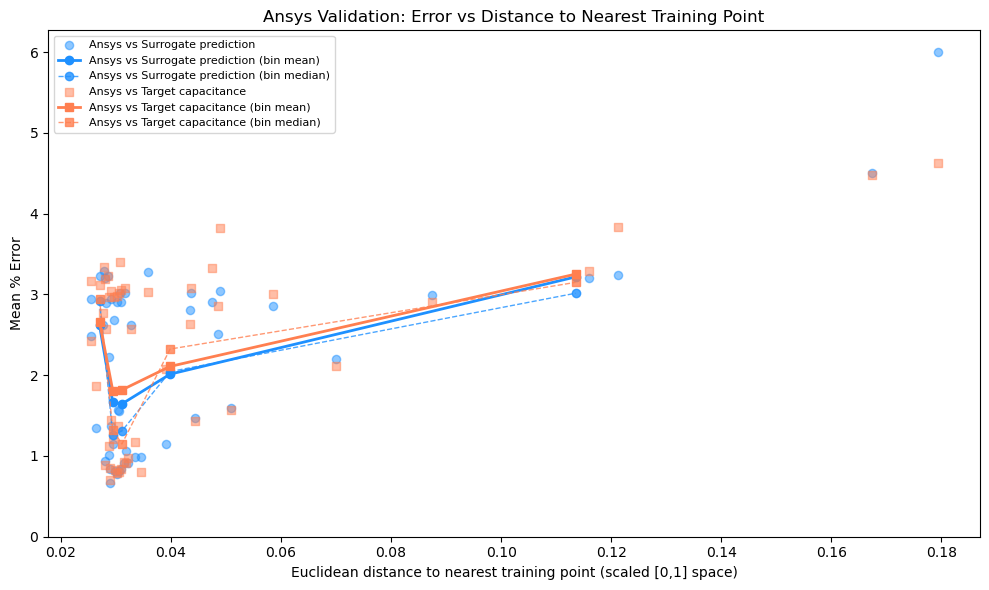

In [25]:
# Plot Ansys errors vs NN distance to nearest training point instead of sigma.

fig, ax = plt.subplots(figsize=(10, 6))

nn = df['nn_dist'].to_numpy()

for label, col, marker, color in [
    ('Ansys vs Surrogate prediction', 'mean_pct_ansys_vs_surrogate', 'o', 'dodgerblue'),
    ('Ansys vs Target capacitance',   'mean_pct_ansys_vs_target',    's', 'coral'),
]:
    y = df[col].to_numpy()
    ax.scatter(nn, y, s=35, alpha=0.5, marker=marker, color=color, label=f'{label}')

    # Binned mean + median curves
    n_bins = 5
    bin_edges = np.quantile(nn, np.linspace(0, 1, n_bins + 1))
    centers, means, medians = [], [], []
    for k in range(n_bins):
        lo, hi = bin_edges[k], bin_edges[k + 1]
        in_bin = (nn >= lo) & (nn <= hi if k == n_bins - 1 else nn < hi)
        if in_bin.sum() < 2:
            continue
        centers.append(0.5 * (lo + hi))
        means.append(y[in_bin].mean())
        medians.append(np.median(y[in_bin]))
    ax.plot(centers, means, f'{marker}-',  color=color, linewidth=2,   label=f'{label} (bin mean)')
    ax.plot(centers, medians, f'{marker}--', color=color, linewidth=1, alpha=0.8,
            label=f'{label} (bin median)')

ax.set_xlabel('Euclidean distance to nearest training point (scaled [0,1] space)')
ax.set_ylabel('Mean % Error')
ax.set_title('Ansys Validation: Error vs Distance to Nearest Training Point')
ax.legend(fontsize=8)
ax.set_ylim(0, None)
plt.tight_layout()
plt.savefig('plots/ansys_validation_error_vs_nn_distance.pdf')
plt.show()


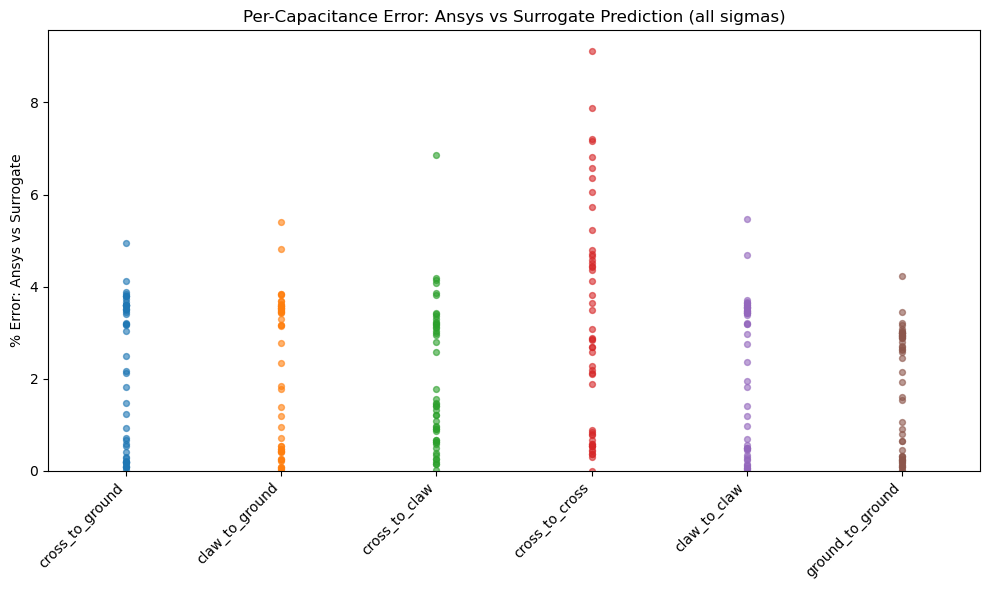

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
for j, cap in enumerate(cap_names):
    col = f'pct_ansys_vs_surrogate_{cap}'
    vals = df[col].values
    ax.scatter(np.full(len(vals), j), vals, s=18, alpha=0.6)
ax.set_xticks(range(len(cap_names)))
ax.set_xticklabels(cap_names, rotation=45, ha='right')
ax.set_ylabel('% Error: Ansys vs Surrogate')
ax.set_title('Per-Capacitance Error: Ansys vs Surrogate Prediction (all sigmas)')
ax.set_ylim(0, None)
ax.margins(y=0)
ax.set_xlim(-0.5, len(cap_names) - 0.5)
plt.tight_layout()
plt.savefig('plots/ansys_vs_surrogate_per_cap.pdf')
plt.show()

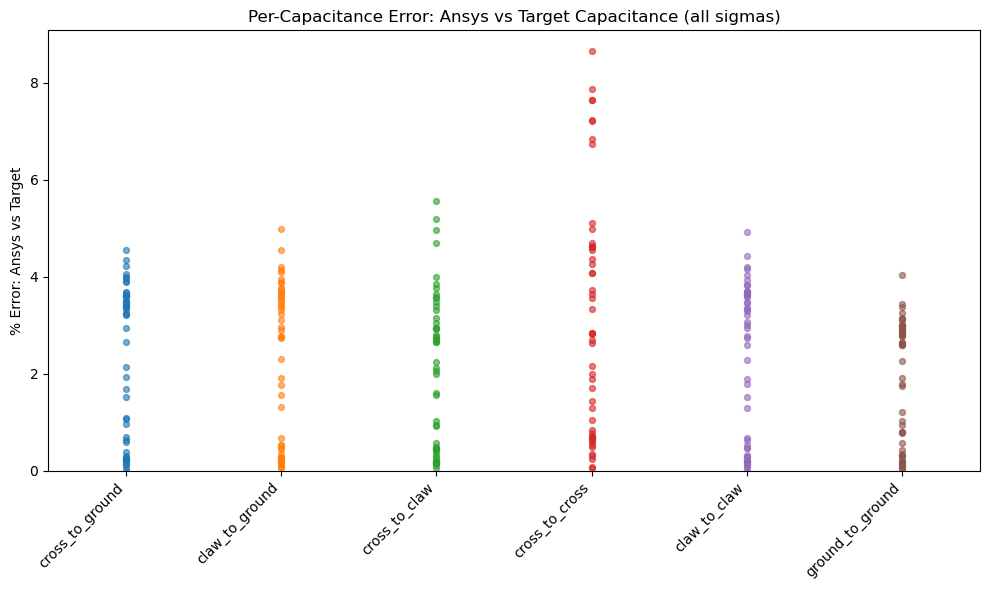

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
for j, cap in enumerate(cap_names):
    col = f'pct_ansys_vs_target_{cap}'
    vals = df[col].values
    ax.scatter(np.full(len(vals), j), vals, s=18, alpha=0.6)
ax.set_xticks(range(len(cap_names)))
ax.set_xticklabels(cap_names, rotation=45, ha='right')
ax.set_ylabel('% Error: Ansys vs Target')
ax.set_title('Per-Capacitance Error: Ansys vs Target Capacitance (all sigmas)')
ax.set_ylim(0, None)
ax.margins(y=0)
ax.set_xlim(-0.5, len(cap_names) - 0.5)
plt.tight_layout()
plt.savefig('plots/ansys_vs_target_per_cap.pdf')
plt.show()

/tmp/ipykernel_19373/40090973.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(_split_by_qbin('mean_pct_ansys_vs_surrogate'),
/tmp/ipykernel_19373/40090973.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(_split_by_qbin('mean_pct_ansys_vs_target'),


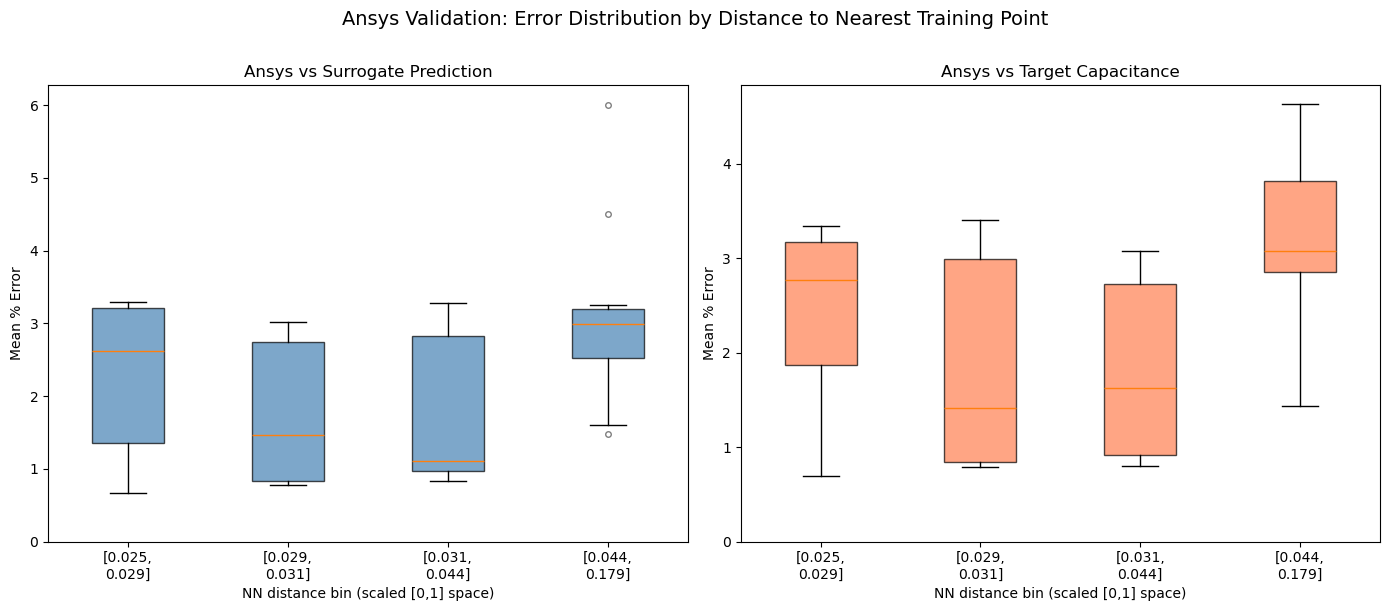

In [28]:
# Boxplots of Ansys error, binned by distance to the nearest training point
# (scaled [0,1] Euclidean).  Using 4 quantile bins so each box has a similar
# sample count regardless of how the sigmas populate the distance axis.

n_qbins = 4
q_edges = np.quantile(df['nn_dist'].to_numpy(), np.linspace(0, 1, n_qbins + 1))
bin_labels = [f'[{q_edges[k]:.3f},\n{q_edges[k+1]:.3f}]' for k in range(n_qbins)]

def _split_by_qbin(col):
    out = []
    nn = df['nn_dist'].to_numpy()
    for k in range(n_qbins):
        lo, hi = q_edges[k], q_edges[k + 1]
        in_bin = (nn >= lo) & (nn <= hi if k == n_qbins - 1 else nn < hi)
        out.append(df[col].to_numpy()[in_bin])
    return out

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Ansys vs Surrogate
bp1 = ax1.boxplot(_split_by_qbin('mean_pct_ansys_vs_surrogate'),
                  labels=bin_labels, patch_artist=True,
                  flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch in bp1['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax1.set_xlabel('NN distance bin (scaled [0,1] space)')
ax1.set_ylabel('Mean % Error')
ax1.set_title('Ansys vs Surrogate Prediction')
ax1.set_ylim(0, None)

# Ansys vs Target
bp2 = ax2.boxplot(_split_by_qbin('mean_pct_ansys_vs_target'),
                  labels=bin_labels, patch_artist=True,
                  flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch in bp2['boxes']:
    patch.set_facecolor('coral')
    patch.set_alpha(0.7)
ax2.set_xlabel('NN distance bin (scaled [0,1] space)')
ax2.set_ylabel('Mean % Error')
ax2.set_title('Ansys vs Target Capacitance')
ax2.set_ylim(0, None)

fig.suptitle('Ansys Validation: Error Distribution by Distance to Nearest Training Point',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/ansys_validation_boxplots_by_nn_distance.pdf')
plt.show()


In [29]:
# Stats table grouped by NN-distance quantile (same 4 bins as the boxplots).

n_qbins = 4
q_edges = np.quantile(df['nn_dist'].to_numpy(), np.linspace(0, 1, n_qbins + 1))

def _bin_mask(k):
    nn = df['nn_dist'].to_numpy()
    lo, hi = q_edges[k], q_edges[k + 1]
    return (nn >= lo) & (nn <= hi if k == n_qbins - 1 else nn < hi)

for title, col in [
    ('Ansys vs Surrogate Prediction', 'mean_pct_ansys_vs_surrogate'),
    ('Ansys vs Target Capacitance',   'mean_pct_ansys_vs_target'),
]:
    print(title)
    print(f'{"NN dist bin":>22s} {"N":>5s} {"Median %":>10s} {"Mean %":>10s} {"Max %":>10s}')
    print('-' * 62)
    for k in range(n_qbins):
        m = _bin_mask(k)
        vals = df.loc[m, col]
        label = f'[{q_edges[k]:.3f}, {q_edges[k+1]:.3f}]'
        if len(vals) == 0:
            print(f'{label:>22s} {0:5d}  (empty)')
            continue
        print(f'{label:>22s} {len(vals):5d} {vals.median():10.2f} {vals.mean():10.2f} {vals.max():10.2f}')
    print()


Ansys vs Surrogate Prediction
           NN dist bin     N   Median %     Mean %      Max %
--------------------------------------------------------------
        [0.025, 0.029]    13       2.62       2.31       3.29
        [0.029, 0.031]    12       1.46       1.70       3.02
        [0.031, 0.044]    12       1.11       1.79       3.27
        [0.044, 0.179]    13       2.99       3.04       6.00

Ansys vs Target Capacitance
           NN dist bin     N   Median %     Mean %      Max %
--------------------------------------------------------------
        [0.025, 0.029]    13       2.77       2.41       3.34
        [0.029, 0.031]    12       1.41       1.89       3.40
        [0.031, 0.044]    12       1.62       1.84       3.08
        [0.044, 0.179]    13       3.08       3.10       4.63



/tmp/ipykernel_19373/40090973.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(_split_by_qbin('mean_pct_ansys_vs_surrogate'),
/tmp/ipykernel_19373/40090973.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(_split_by_qbin('mean_pct_ansys_vs_target'),


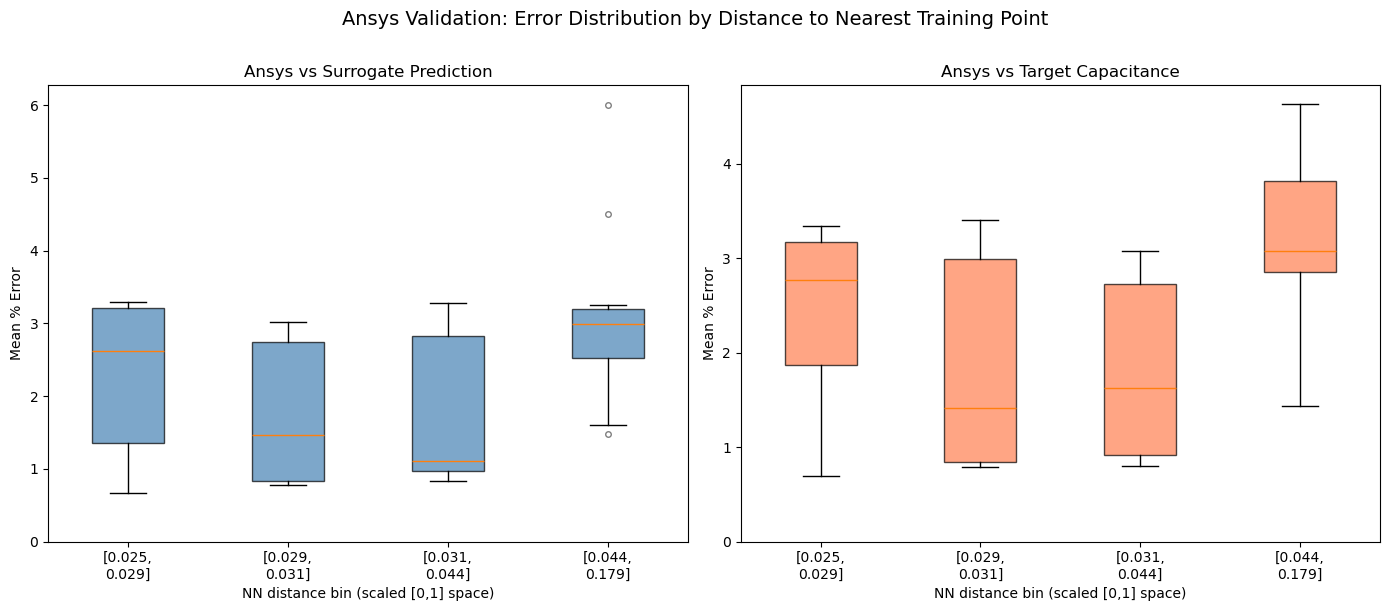

In [30]:
# Boxplots of Ansys error, binned by distance to the nearest training point
# (scaled [0,1] Euclidean).  Using 4 quantile bins so each box has a similar
# sample count regardless of how the sigmas populate the distance axis.

n_qbins = 4
q_edges = np.quantile(df['nn_dist'].to_numpy(), np.linspace(0, 1, n_qbins + 1))
bin_labels = [f'[{q_edges[k]:.3f},\n{q_edges[k+1]:.3f}]' for k in range(n_qbins)]

def _split_by_qbin(col):
    out = []
    nn = df['nn_dist'].to_numpy()
    for k in range(n_qbins):
        lo, hi = q_edges[k], q_edges[k + 1]
        in_bin = (nn >= lo) & (nn <= hi if k == n_qbins - 1 else nn < hi)
        out.append(df[col].to_numpy()[in_bin])
    return out

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Ansys vs Surrogate
bp1 = ax1.boxplot(_split_by_qbin('mean_pct_ansys_vs_surrogate'),
                  labels=bin_labels, patch_artist=True,
                  flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch in bp1['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax1.set_xlabel('NN distance bin (scaled [0,1] space)')
ax1.set_ylabel('Mean % Error')
ax1.set_title('Ansys vs Surrogate Prediction')
ax1.set_ylim(0, None)

# Ansys vs Target
bp2 = ax2.boxplot(_split_by_qbin('mean_pct_ansys_vs_target'),
                  labels=bin_labels, patch_artist=True,
                  flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch in bp2['boxes']:
    patch.set_facecolor('coral')
    patch.set_alpha(0.7)
ax2.set_xlabel('NN distance bin (scaled [0,1] space)')
ax2.set_ylabel('Mean % Error')
ax2.set_title('Ansys vs Target Capacitance')
ax2.set_ylim(0, None)

fig.suptitle('Ansys Validation: Error Distribution by Distance to Nearest Training Point',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/ansys_validation_boxplots_by_nn_distance.pdf')
plt.show()


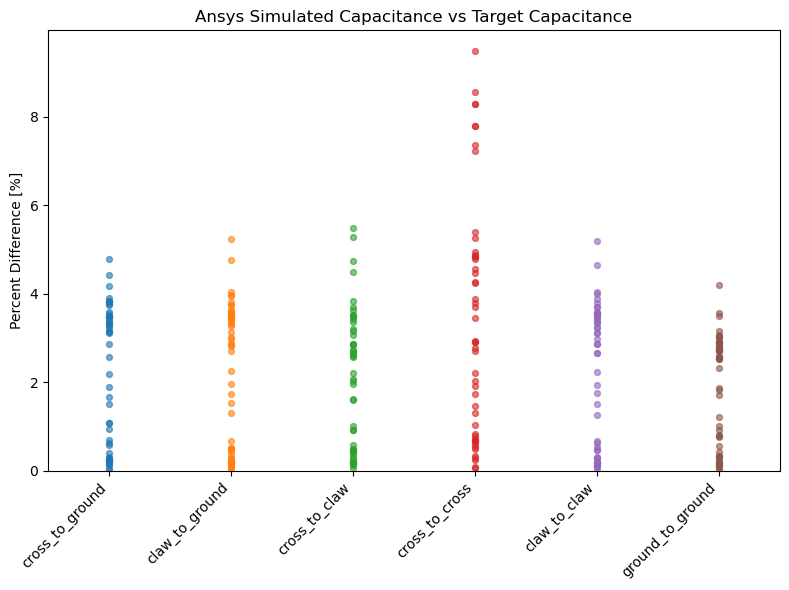

Cap Column                  Median %     Mean %      Max %
-------------------------------------------------------
cross_to_ground                 3.13       2.27       4.78
claw_to_ground                  2.86       2.25       5.25
cross_to_claw                   2.14       2.04       5.49
cross_to_cross                  2.91       3.31       9.47
claw_to_claw                    2.86       2.23       5.19
ground_to_ground                2.54       1.85       4.20
-------------------------------------------------------
All (avg per sample)            2.62       2.33       4.91


In [31]:
df = pd.read_csv('best_candidates_for_ansys_validation-with_Ansys.csv')

cap_names = ['cross_to_ground', 'claw_to_ground', 'cross_to_claw',
             'cross_to_cross', 'claw_to_claw', 'ground_to_ground']
eps = 1e-15

# % error: Ansys result vs what we were aiming for (target from test set)
for cap in cap_names:
    df[f'pct_err_{cap}'] = 100 * abs(df[f'ansys_{cap}'] - df[f'target_{cap}']) / (abs(df[f'target_{cap}']) + eps)

df['mean_pct_err'] = df[[f'pct_err_{c}' for c in cap_names]].mean(axis=1)
sigmas = sorted(df['sigma_for_gauss'].unique())

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
for j, cap in enumerate(cap_names):
    vals = df[f'pct_err_{cap}'].values
    ax.scatter(np.full(len(vals), j), vals, s=18, alpha=0.6)
ax.set_xticks(range(len(cap_names)))
ax.set_xticklabels(cap_names, rotation=45, ha='right')
ax.set_ylabel('Percent Difference [%]')
ax.set_title('Ansys Simulated Capacitance vs Target Capacitance')
ax.set_ylim(0, None)
ax.margins(y=0)
ax.set_xlim(-0.5, len(cap_names) - 0.5)
plt.tight_layout()
plt.savefig('plots/ansys_vs_target_scatter.pdf')
plt.show()

# Stats
print(f'{"Cap Column":<25s} {"Median %":>10s} {"Mean %":>10s} {"Max %":>10s}')
print('-' * 55)
for cap in cap_names:
    vals = df[f'pct_err_{cap}']
    print(f'{cap:<25s} {vals.median():10.2f} {vals.mean():10.2f} {vals.max():10.2f}')
print('-' * 55)
all_vals = df['mean_pct_err']
print(f'{"All (avg per sample)":<25s} {all_vals.median():10.2f} {all_vals.mean():10.2f} {all_vals.max():10.2f}')

In [32]:
# Ratio: how much error does the surrogate ADD vs the natural physical variation?
for cap in cap_names:
    df[f'ratio_{cap}'] = abs(df[f'ansys_{cap}'] - df[f'surrogate_pred_{cap}']) / (abs(df[f'ansys_{cap}'] - df[f'target_{cap}']) + eps)

df['mean_ratio'] = df[[f'ratio_{c}' for c in cap_names]].mean(axis=1)

print('Ratio of surrogate error to physical variation (lower = surrogate adds less noise):')
print(f'{"Sigma %":>10s} {"Median":>10s} {"Mean":>10s}')
print('-' * 35)
for s in sigmas:
    sub = df[df['sigma_for_gauss'] == s]['mean_ratio']
    print(f'{s:10d} {sub.median():10.3f} {sub.mean():10.3f}')

Ratio of surrogate error to physical variation (lower = surrogate adds less noise):
   Sigma %     Median       Mean
-----------------------------------
         1      0.949      1.161
         2      0.959      0.948
         5      1.005      1.045
        10      1.081      1.319
        20      0.980      1.100


Running 1-NN baseline ...
Running k-NN (k=5) baseline ...


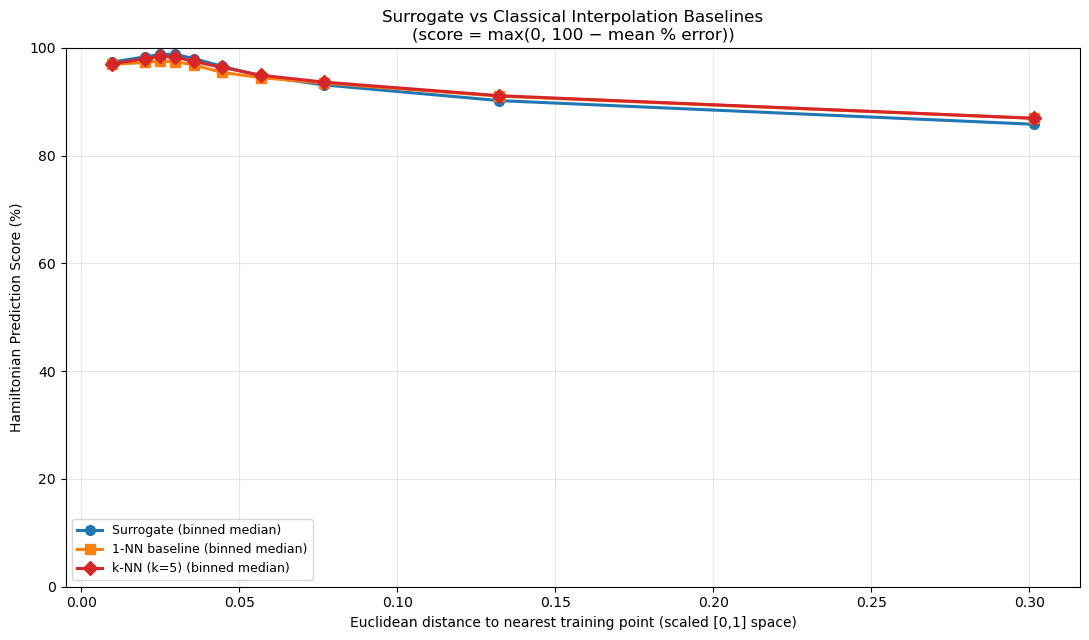

In [44]:
from sklearn.neighbors import NearestNeighbors

# --- Training data: inputs = scaled qiskit params, outputs = scaled Hamiltonian ---
X_train_scaled_np = np.asarray(X_train).astype("float64")
y_train_scaled_np = np.asarray(y_train).astype("float64")

# --- Fit baselines ---
nn1 = NearestNeighbors(n_neighbors=1).fit(X_train_scaled_np)
nnK = NearestNeighbors(n_neighbors=5).fit(X_train_scaled_np)

def predict_1nn(points_scaled):
    _, idx = nn1.kneighbors(points_scaled)
    return y_train_scaled_np[idx[:, 0]]

def predict_knn(points_scaled, k=5, eps=1e-12):
    d, idx = nnK.kneighbors(points_scaled)
    w = 1.0 / (d + eps)
    w /= w.sum(axis=1, keepdims=True)
    out = np.zeros((points_scaled.shape[0], y_train_scaled_np.shape[1]))
    for c in range(y_train_scaled_np.shape[1]):
        out[:, c] = (w * y_train_scaled_np[idx, c]).sum(axis=1)
    return out

# --- Collect augmented samples + targets from all_results ---
sigmas = sorted(all_results.keys())
all_pts_scaled      = np.concatenate([all_results[s]["augmented_scaled"]            for s in sigmas]).astype("float64")
all_nn              = np.concatenate([all_results[s]["nn_dist"]                     for s in sigmas])
all_surr_err        = np.concatenate([all_results[s]["mean_pct_per_sample"]         for s in sigmas])
all_target_unscaled = np.concatenate([all_results[s]["target_Hamiltonian_unscaled"] for s in sigmas])

# --- Run the baselines ---
print("Running 1-NN baseline ...")
pred_1nn_unscaled = unscale_Hamiltonian(predict_1nn(all_pts_scaled))
print("Running k-NN (k=5) baseline ...")
pred_knn_unscaled = unscale_Hamiltonian(predict_knn(all_pts_scaled))

eps = 1e-15
def mean_pct_err(pred_unscaled, target_unscaled):
    pe = 100.0 * np.abs(pred_unscaled - target_unscaled) / (np.abs(target_unscaled) + eps)
    return pe.mean(axis=1)

all_1nn_err = mean_pct_err(pred_1nn_unscaled, all_target_unscaled)
all_knn_err = mean_pct_err(pred_knn_unscaled, all_target_unscaled)

# --- Convert error to "accuracy score" ---
def to_accuracy_score(err):
    return np.maximum(0.0, 100.0 - err)   # clip at 0 to avoid negative "accuracy"

all_surr_acc = to_accuracy_score(all_surr_err)
all_1nn_acc  = to_accuracy_score(all_1nn_err)
all_knn_acc  = to_accuracy_score(all_knn_err)

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 6.5))

series = [
    ("Surrogate",     all_surr_acc, "tab:blue",   "o"),
    ("1-NN baseline", all_1nn_acc,  "tab:orange", "s"),
    ("k-NN (k=5)",    all_knn_acc,  "tab:red",    "D"),
]

n_bins = 10
q_edges = np.quantile(all_nn, np.linspace(0, 1, n_bins + 1))
centers = 0.5 * (q_edges[:-1] + q_edges[1:])

for label, y, color, marker in series:
    medians = []
    for k in range(n_bins):
        lo, hi = q_edges[k], q_edges[k + 1]
        in_bin = (all_nn >= lo) & (all_nn <= hi if k == n_bins - 1 else all_nn < hi)
        medians.append(np.median(y[in_bin]) if in_bin.sum() else np.nan)

    ax.plot(
        centers, medians, marker + "-",
        color=color, linewidth=2.2, markersize=7,
        label=f"{label} (binned median)"
    )

ax.set_xlabel("Euclidean distance to nearest training point (scaled [0,1] space)")
ax.set_ylabel("Hamiltonian Prediction Score (%)")
ax.set_title("Surrogate vs Classical Interpolation Baselines\n(score = max(0, 100 − mean % error))")
ax.legend(fontsize=9, loc="best")
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig("plots/surrogate_vs_baselines_score_vs_nn_distance_no_errorbars.pdf")
plt.show()

Running 1-NN baseline ...
Running k-NN (k=5) baseline ...


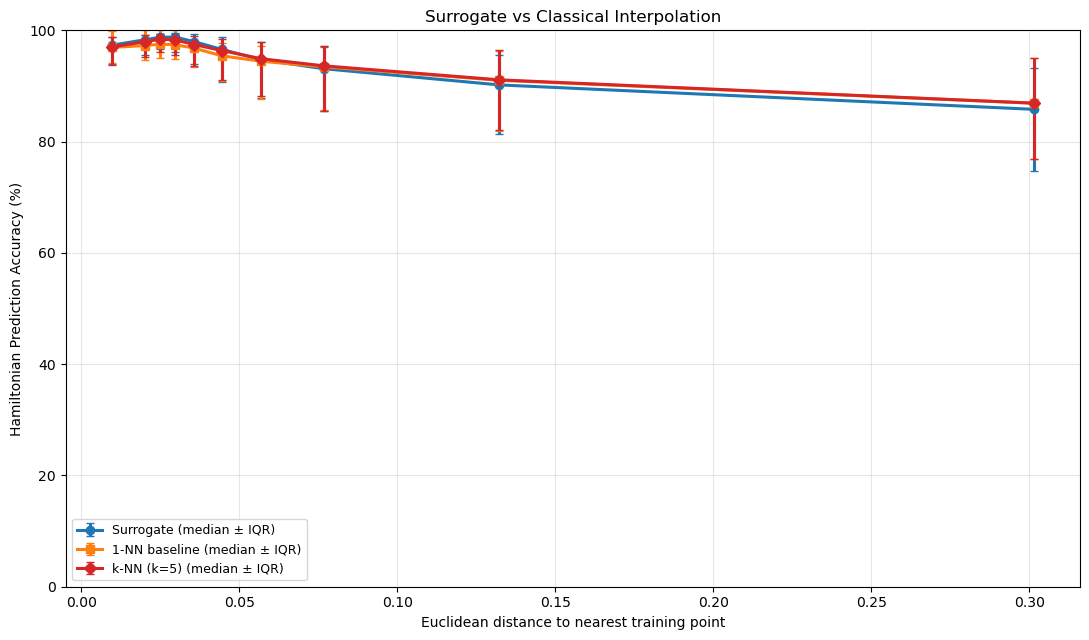

In [48]:
from sklearn.neighbors import NearestNeighbors

# --- Training data: inputs = scaled qiskit params, outputs = scaled Hamiltonian ---
X_train_scaled_np = np.asarray(X_train).astype("float64")
y_train_scaled_np = np.asarray(y_train).astype("float64")

# --- Fit baselines ---
nn1 = NearestNeighbors(n_neighbors=1).fit(X_train_scaled_np)
nnK = NearestNeighbors(n_neighbors=5).fit(X_train_scaled_np)

def predict_1nn(points_scaled):
    _, idx = nn1.kneighbors(points_scaled)
    return y_train_scaled_np[idx[:, 0]]

def predict_knn(points_scaled, k=5, eps=1e-12):
    d, idx = nnK.kneighbors(points_scaled)
    w = 1.0 / (d + eps)
    w /= w.sum(axis=1, keepdims=True)
    out = np.zeros((points_scaled.shape[0], y_train_scaled_np.shape[1]))
    for c in range(y_train_scaled_np.shape[1]):
        out[:, c] = (w * y_train_scaled_np[idx, c]).sum(axis=1)
    return out

# --- Collect augmented samples + targets from all_results ---
sigmas = sorted(all_results.keys())
all_pts_scaled      = np.concatenate([all_results[s]["augmented_scaled"]            for s in sigmas]).astype("float64")
all_nn              = np.concatenate([all_results[s]["nn_dist"]                     for s in sigmas])
all_surr_err        = np.concatenate([all_results[s]["mean_pct_per_sample"]         for s in sigmas])
all_target_unscaled = np.concatenate([all_results[s]["target_Hamiltonian_unscaled"] for s in sigmas])

# --- Run the baselines ---
print("Running 1-NN baseline ...")
pred_1nn_unscaled = unscale_Hamiltonian(predict_1nn(all_pts_scaled))
print("Running k-NN (k=5) baseline ...")
pred_knn_unscaled = unscale_Hamiltonian(predict_knn(all_pts_scaled))

eps = 1e-15
def mean_pct_err(pred_unscaled, target_unscaled):
    pe = 100.0 * np.abs(pred_unscaled - target_unscaled) / (np.abs(target_unscaled) + eps)
    return pe.mean(axis=1)

all_1nn_err = mean_pct_err(pred_1nn_unscaled, all_target_unscaled)
all_knn_err = mean_pct_err(pred_knn_unscaled, all_target_unscaled)

# --- Convert error to "accuracy score" ---
def to_accuracy_score(err):
    return np.maximum(0.0, 100.0 - err)

all_surr_acc = to_accuracy_score(all_surr_err)
all_1nn_acc  = to_accuracy_score(all_1nn_err)
all_knn_acc  = to_accuracy_score(all_knn_err)

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 6.5))

series = [
    ("Surrogate",     all_surr_acc, "tab:blue",   "o"),
    ("1-NN baseline", all_1nn_acc,  "tab:orange", "s"),
    ("k-NN (k=5)",    all_knn_acc,  "tab:red",    "D"),
]

n_bins = 10
q_edges = np.quantile(all_nn, np.linspace(0, 1, n_bins + 1))
centers = 0.5 * (q_edges[:-1] + q_edges[1:])

for label, y, color, marker in series:
    medians = []
    yerr_low = []
    yerr_high = []

    for k in range(n_bins):
        lo, hi = q_edges[k], q_edges[k + 1]
        in_bin = (all_nn >= lo) & (all_nn <= hi if k == n_bins - 1 else all_nn < hi)

        if in_bin.sum():
            y_bin = y[in_bin]
            med = np.median(y_bin)
            q25 = np.percentile(y_bin, 25)
            q75 = np.percentile(y_bin, 75)

            medians.append(med)
            yerr_low.append(med - q25)
            yerr_high.append(q75 - med)
        else:
            medians.append(np.nan)
            yerr_low.append(np.nan)
            yerr_high.append(np.nan)

    medians = np.array(medians)
    yerr = np.vstack([yerr_low, yerr_high])

    ax.errorbar(
        centers,
        medians,
        yerr=yerr,
        fmt=marker + "-",
        color=color,
        linewidth=2.2,
        markersize=6,
        capsize=3,
        label=f"{label} (median ± IQR)"
    )

ax.set_xlabel("Euclidean distance to nearest training point")
ax.set_ylabel("Hamiltonian Prediction Accuracy (%)")
ax.set_title("Surrogate vs Classical Interpolation")
ax.legend(fontsize=9, loc="best")
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig("plots/surrogate_vs_baselines_score_vs_nn_distance_with_errorbars.pdf")
plt.show()

Loaded 90 Ansys-validated points from MLP_Ansys_results_random_stress_test.csv
NN-distance range:  min=0.0126  median=0.0388  max=0.3462
Ansys-value reconstruction:  median |error| = 0.0592%  max = 7.0978%


/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/tmp/ipykernel_19373/2263515282.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


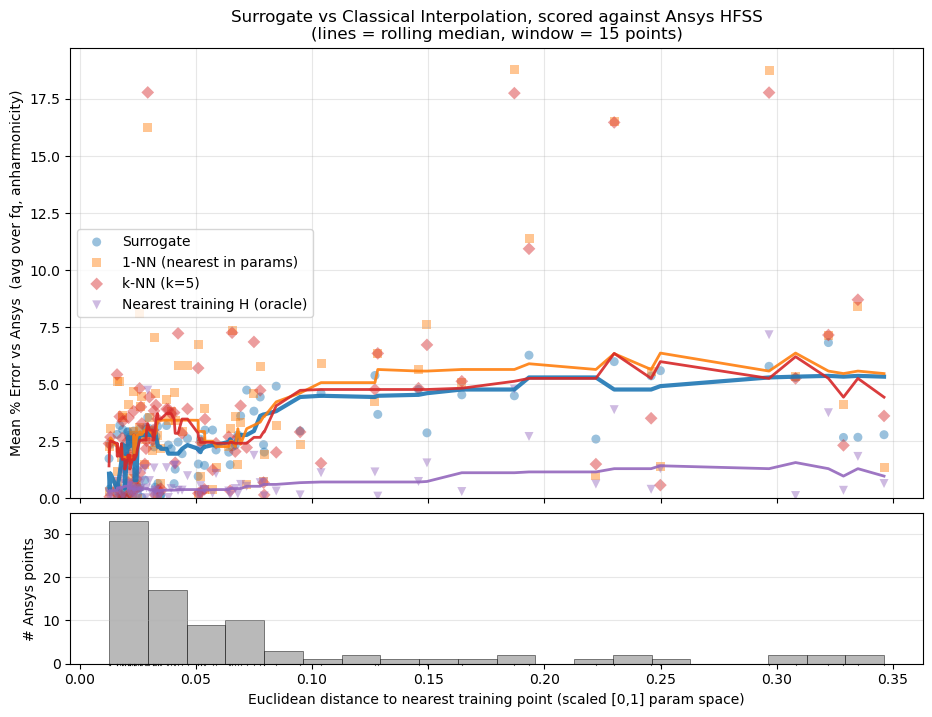


         NN dist bin     N     Surr     1-NN     k-NN   Oracle
--------------------------------------------------------------
      [0.013, 0.022]    18     2.01     1.83     1.81     0.47
      [0.022, 0.032]    18     2.78     2.86     2.55     0.41
      [0.032, 0.052]    18     2.07     3.43     3.60     0.37
      [0.052, 0.097]    18     2.63     2.44     2.44     0.38
      [0.097, 0.346]    18     4.69     5.78     5.20     1.14

Overall median vs Ansys:  surrogate=2.68%  1-NN=3.05%  k-NN=2.66%  oracle=0.43%
Overall mean   vs Ansys:  surrogate=2.55%  1-NN=3.89%  k-NN=3.50%  oracle=0.85%
Fraction of points where surrogate beats 1-NN:    67.8%
Fraction of points where surrogate beats k-NN:    61.1%
Fraction of points where surrogate beats oracle:  21.1%


In [35]:
# =====================================================================
# Stress test: surrogate vs classical interpolators, scored against
# Ansys ground truth, as a function of distance to the nearest training
# point.
#
# For each of the ~90 Ansys-validated noisy points:
#   1. Compute NN-distance to the closest training sample (Euclidean in
#      scaled [0,1] qiskit-param space).
#   2. Predict the Hamiltonian (fq, alpha) three ways, plus an oracle:
#        - Surrogate              (already in the CSV as surrogate_pred_*)
#        - 1-NN                   (nearest-in-param-space training point's H)
#        - k-NN (k=5)             (inverse-dist-weighted avg of 5 nearest)
#        - Nearest training H     (oracle: the training point whose H is
#                                  closest to the Ansys H - a lower bound
#                                  on how close any training sample can get)
#   3. Score each method as mean |pct err| over (fq, alpha) against Ansys.
#   4. Plot % error vs param-space NN-distance for all four, with a
#      second panel below showing the NN-distance distribution.
# =====================================================================

from sklearn.neighbors import NearestNeighbors

# --- Load the Ansys-validated CSV (Hamiltonian-space) -----------------
MLP_ANSYS_CSV = "MLP_Ansys_results_random_stress_test.csv"
df_H = pd.read_csv(MLP_ANSYS_CSV)
print(f"Loaded {len(df_H)} Ansys-validated points from {MLP_ANSYS_CSV}")

# --- Compute param-space NN-distance for each noisy point -------------
param_cols_H = [
    "design_options.connection_pads.readout.claw_length",
    "design_options.connection_pads.readout.ground_spacing",
    "design_options.cross_length",
]
df_H_params_unscaled = df_H[param_cols_H].to_numpy(dtype="float64")
df_H_params_scaled   = scale_qiskit(df_H_params_unscaled)
df_H["nn_dist"]      = nearest_train_distance(df_H_params_scaled)

print(f"NN-distance range:  min={df_H['nn_dist'].min():.4f}  "
      f"median={df_H['nn_dist'].median():.4f}  max={df_H['nn_dist'].max():.4f}")

# --- Reconstruct Ansys Hamiltonian values from the CSV ----------------
def _recover_ansys(target, pd_target, surr, pd_surr_reported):
    pd_t = pd_target / 100.0
    cand_plus  = target / (1.0 + pd_t)
    cand_minus = target / (1.0 - pd_t)
    pds_plus   = 100.0 * np.abs(surr - cand_plus)  / np.abs(cand_plus)
    pds_minus  = 100.0 * np.abs(surr - cand_minus) / np.abs(cand_minus)
    use_plus = np.abs(pds_plus - pd_surr_reported) < np.abs(pds_minus - pd_surr_reported)
    return np.where(use_plus, cand_plus, cand_minus)

ansys_fq    = _recover_ansys(
    df_H["target_qubit_frequency_GHz"].to_numpy(),
    df_H["pd_fq_target_vs_ansys"].to_numpy(),
    df_H["surrogate_pred_qubit_frequency_GHz"].to_numpy(),
    df_H["pd_fq_surrogate_vs_ansys"].to_numpy(),
)
ansys_alpha = _recover_ansys(
    df_H["target_anharmonicity_MHz"].to_numpy(),
    df_H["pd_alpha_target_vs_ansys"].to_numpy(),
    df_H["surrogate_pred_anharmonicity_MHz"].to_numpy(),
    df_H["pd_alpha_surrogate_vs_ansys"].to_numpy(),
)
ansys_vec = np.column_stack([ansys_fq, ansys_alpha])

_check = 100.0 * np.abs(df_H["surrogate_pred_qubit_frequency_GHz"].to_numpy() - ansys_fq) / np.abs(ansys_fq)
_diff  = np.abs(_check - df_H["pd_fq_surrogate_vs_ansys"].to_numpy())
print(f"Ansys-value reconstruction:  median |error| = {np.median(_diff):.4f}%  "
      f"max = {_diff.max():.4f}%")

# --- Fit classical baselines on the surrogate's training set ----------
X_train_scaled_np = np.asarray(X_train).astype("float64")
y_train_scaled_np = np.asarray(y_train).astype("float64")

nn1 = NearestNeighbors(n_neighbors=1).fit(X_train_scaled_np)
nnK = NearestNeighbors(n_neighbors=5).fit(X_train_scaled_np)

# --- 1-NN and k-NN predictions at the 90 Ansys points -----------------
_, idx_1nn = nn1.kneighbors(df_H_params_scaled)
pred_1nn_scaled = y_train_scaled_np[idx_1nn[:, 0]]

dK, idxK = nnK.kneighbors(df_H_params_scaled)
wK = 1.0 / (dK + 1e-12)
wK /= wK.sum(axis=1, keepdims=True)
pred_knn_scaled = np.zeros((len(df_H), 2))
for c in range(2):
    pred_knn_scaled[:, c] = (wK * y_train_scaled_np[idxK, c]).sum(axis=1)

pred_1nn = unscale_Hamiltonian(pred_1nn_scaled)
pred_knn = unscale_Hamiltonian(pred_knn_scaled)

# --- Nearest-training-H oracle ---------------------------------------
# For each Ansys point, find the training point whose Hamiltonian is
# CLOSEST to the Ansys Hamiltonian (nearest neighbor in H space).
# Distance is computed in scaled Hamiltonian space so fq (GHz) and
# alpha (MHz) contribute proportionally.  This is a lower bound on how
# well any NN-style method that picks from the training set could do.
unscaled_y_train = unscale_Hamiltonian(y_train_scaled_np)
H_mins  = unscaled_y_train.min(axis=0)
H_maxs  = unscaled_y_train.max(axis=0)
H_range = np.maximum(H_maxs - H_mins, 1e-12)

y_train_Hspace_scaled = (unscaled_y_train - H_mins) / H_range
ansys_Hspace_scaled   = (ansys_vec         - H_mins) / H_range

nn_H = NearestNeighbors(n_neighbors=1).fit(y_train_Hspace_scaled)
_, idx_oracle = nn_H.kneighbors(ansys_Hspace_scaled)
pred_oracle = unscaled_y_train[idx_oracle[:, 0]]

# --- Score each method against Ansys ----------------------------------
def _mean_pct_vs_ansys(pred):
    pe = 100.0 * np.abs(pred - ansys_vec) / (np.abs(ansys_vec) + 1e-15)
    return pe.mean(axis=1)

# Surrogate error comes straight from the CSV (no reconstruction needed)
err_surr   = 0.5 * (
    df_H["pd_fq_surrogate_vs_ansys"].abs().to_numpy()
  + df_H["pd_alpha_surrogate_vs_ansys"].abs().to_numpy()
)
err_1nn    = _mean_pct_vs_ansys(pred_1nn)
err_knn    = _mean_pct_vs_ansys(pred_knn)
err_oracle = _mean_pct_vs_ansys(pred_oracle)

# --- Plot: two panels sharing x-axis ----------------------------------
fig, (ax, ax_d) = plt.subplots(
    2, 1, figsize=(11, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

nn = df_H["nn_dist"].to_numpy()
order = np.argsort(nn)
nn_sorted = nn[order]

ROLL_W = 15  # rolling-median window; ~17% of 90 points

def _rolling_median(y_sorted, w):
    s = pd.Series(y_sorted)
    return s.rolling(window=w, center=True, min_periods=max(3, w // 2)).median().to_numpy()

series = [
    ("Surrogate",               err_surr,   "tab:blue",   "o", 3.0),
    ("1-NN (nearest in params)", err_1nn,   "tab:orange", "s", 2.0),
    ("k-NN (k=5)",              err_knn,    "tab:red",    "D", 2.0),
    ("Nearest training H (oracle)", err_oracle, "tab:purple", "v", 2.0),
]

# Top: scatter every point, every method
for label, y, color, marker, _ in series:
    ax.scatter(nn, y, s=42, alpha=0.45, color=color, marker=marker,
               edgecolors="none", label=label)

# Top: rolling-median trend line per method
for label, y, color, marker, lw in series:
    y_sorted = y[order]
    y_roll = _rolling_median(y_sorted, ROLL_W)
    ax.plot(nn_sorted, y_roll, "-", color=color, linewidth=lw, alpha=0.9)

ax.set_ylabel("Mean % Error vs Ansys  (avg over fq, anharmonicity)")
ax.set_title("Surrogate vs Classical Interpolation, scored against Ansys HFSS\n"
             f"(lines = rolling median, window = {ROLL_W} points)")
ax.legend(fontsize=10, loc="best")
ax.grid(True, alpha=0.3)
ax.set_ylim(0, None)

# Bottom: NN-distance distribution across the 90 points
ax_d.hist(nn, bins=20, color="gray", alpha=0.55, edgecolor="black", linewidth=0.6)
for xv in nn:
    ax_d.plot([xv, xv], [-0.4, -0.1], color="black", linewidth=0.8, alpha=0.6, clip_on=False)
ax_d.set_xlabel("Euclidean distance to nearest training point (scaled [0,1] param space)")
ax_d.set_ylabel("# Ansys points")
ax_d.grid(True, axis="y", alpha=0.3)
ax_d.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("plots/ansys_stress_test_surr_vs_nn_with_density.pdf")
plt.show()

# --- Numeric summary (quantile bins for the table) --------------------
print()
n_bins = 5
q_edges = np.quantile(nn, np.linspace(0, 1, n_bins + 1))
print(f'{"NN dist bin":>20s} {"N":>5s} {"Surr":>8s} {"1-NN":>8s} {"k-NN":>8s} {"Oracle":>8s}')
print("-" * 62)
for k in range(n_bins):
    lo, hi = q_edges[k], q_edges[k + 1]
    in_bin = (nn >= lo) & (nn <= hi if k == n_bins - 1 else nn < hi)
    if not in_bin.sum():
        continue
    label = f"[{lo:.3f}, {hi:.3f}]"
    print(f'{label:>20s} {in_bin.sum():5d} '
          f'{np.median(err_surr[in_bin]):8.2f} '
          f'{np.median(err_1nn[in_bin]):8.2f} '
          f'{np.median(err_knn[in_bin]):8.2f} '
          f'{np.median(err_oracle[in_bin]):8.2f}')

print()
print(f"Overall median vs Ansys:  surrogate={np.median(err_surr):.2f}%  "
      f"1-NN={np.median(err_1nn):.2f}%  "
      f"k-NN={np.median(err_knn):.2f}%  "
      f"oracle={np.median(err_oracle):.2f}%")
print(f"Overall mean   vs Ansys:  surrogate={err_surr.mean():.2f}%  "
      f"1-NN={err_1nn.mean():.2f}%  "
      f"k-NN={err_knn.mean():.2f}%  "
      f"oracle={err_oracle.mean():.2f}%")
print(f"Fraction of points where surrogate beats 1-NN:    {(err_surr <= err_1nn).mean()*100:.1f}%")
print(f"Fraction of points where surrogate beats k-NN:    {(err_surr <= err_knn).mean()*100:.1f}%")
print(f"Fraction of points where surrogate beats oracle:  {(err_surr <= err_oracle).mean()*100:.1f}%")
